In [14]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway


import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,calculate_speed,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices
from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
test = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint.h5")
test1 = pd.read_hdf(r"D:\obstacle_avoidance\metadata\obstacle_avoidance_paper\joint1.h5")
joint = pd.concat([test,test1])
intial_distance_to_obstacle(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)

In [12]:
joint[:7276].to_hdf(r'd:\obstacle_avoidance\metadata\obstacle_avoidance_paper/joint.h5', key='df', mode='w')

In [13]:
joint[7276:].to_hdf(r'd:\obstacle_avoidance\metadata\obstacle_avoidance_paper/joint1.h5', key='df', mode='w')

In [316]:

font = {'family' : 'arial',
        'weight' : 'bold',
        'size'   : 24}

plt.rc( 'font',**font);

In [22]:
plt.rcParams.update({'font.size': 24,
                     'font.weight': 'bold',
                     'axes.linewidth':    1,
                     'xtick.major.size':  3,
                     'xtick.major.width': 1,
                     'ytick.major.size':  3,
                     'ytick.major.width': 1,
                     'axes.spines.right': False,
                     'axes.spines.top':   False,
                     'pdf.fonttype':      42,
                     'xtick.labelsize':   24,
                     'ytick.labelsize':   24,
                     'figure.facecolor': 'white'
                    })

In [120]:
np.round(row[1].ts_distance_from_edge[0])

9.0

In [121]:
def intial_distance_to_obstacle(df):
    for ind,row in df.iterrows():
        df.at[ind,'intial_distance'] = np.round(row.ts_distance_from_edge[0])

In [4]:
def distance_at_head_turn_2(df):
    for ind,row in df.iterrows():
        peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3,12))
        if len(peaks) == 0:
            df.at[ind,'distance_at_head_turn_2'] = np.nan
            df.at[ind,'distance_at_head_turn_2_index'] = np.nan
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.nan
            df.at[ind,'angle_at_head_turn_2'] = np.nan
            df.at[ind,'num_turn'] = 0
        else:
            max_peak = peaks[prop['peak_heights'].argmax()]
  
            df.at[ind,'distance_at_head_turn_2'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'distance_at_head_turn_2_index'] = max_peak
            df.at[ind,'distance_at_head_turn_2_indexs'] = np.array(peaks).astype(object)
            df.at[ind,'angle_at_head_turn_2'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'num_turn'] = len(peaks)
def towards_away_turns(df):
    for ind,row in df.iterrows():
        pos_peaks, pos_prop = find_peaks(row.head_corner_angle_velocity[:int(row.obstacle_ind)], width=1,height=(2,12))
        neg_peaks, neg_prop = find_peaks((row.head_corner_angle_velocity[:int(row.obstacle_ind)])*-1, width=1,height=(2,12))
        if len(pos_peaks) == 0:
            df.at[ind,'towards_num_turn'] = 0
        elif len(neg_peaks) == 0: 
            df.at[ind,'away_num_turn'] = 0  
        else:
            df.at[ind,'towards_num_turn'] = len(pos_peaks)
            df.at[ind,'away_num_turn'] = len(neg_peaks)
def right_left_turns(df):
    for ind,row in df.iterrows():
        pos_peaks, pos_prop = find_peaks(row.head_angle_velocity[:int(row.obstacle_ind)], width=2,height=(3,12))
        neg_peaks, neg_prop = find_peaks(row.head_angle_velocity[:int(row.obstacle_ind)]*-1, width=2,height=(3,12))
        
        if row.odd == 'right':
            df.at[ind,'right_num_turn'] = len(neg_peaks)
            df.at[ind,'right_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][neg_peaks]
            df.at[ind,'left_num_turn'] = len(pos_peaks)
            df.at[ind,'left_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][pos_peaks]
        elif row.odd == 'left':
            df.at[ind,'right_num_turn'] = len(pos_peaks)
            df.at[ind,'right_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][pos_peaks]
            df.at[ind,'left_num_turn'] = len(neg_peaks)
            df.at[ind,'left_turns_distances'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][neg_peaks]
def first_occurrence_indices(arr):
    unique_values, first_indices = np.unique(arr, return_index=True)
    sorted_indices = np.sort(first_indices)
    return sorted_indices

In [5]:
light = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\light_092524_oa.h5")
dark = pd.read_hdf(r"D:\obstacle_avoidance\metadata\SFN\data\dark_092524_oa.h5")
joint = pd.concat([light,dark])
heading_calcs(joint)
get_head_angle(joint)
head_angle_velocity(joint)
angular_velocity_head_corner(joint)
distance_at_head_turn_2(joint)
towards_away_turns(joint)
right_left_turns(joint)
#con_df = create_consective_df_new(joint)

long_nostart,short_nostart,middle_nostart = create_df_by_type_nostart(joint)
#long_con_nostart,short_con_nostart,middle_con_nostart = create_df_by_type_nostart(con_df)

long,short,middle = create_df_by_type(joint)
#long_con,short_con,middle_con = create_df_by_type(con_df)

corner
port


In [131]:
def first_occurrence_indices(arr):
    unique_values, first_indices = np.unique(arr, return_index=True)
    sorted_indices = np.sort(first_indices)
    return sorted_indices

Light single trial 


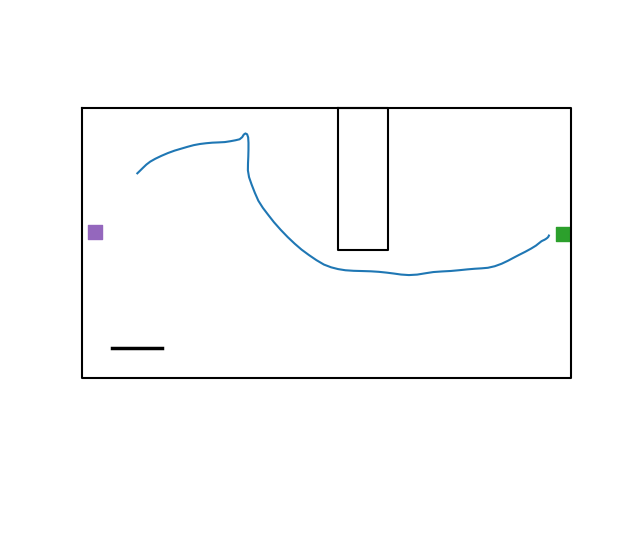

In [514]:
data = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oa')&(long_nostart.turn_to_obstacle == 'towards')]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
sample_light = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample_light.iterrows():
    fig,ax = plt.subplots(1,1,figsize=(8,7))
    
    #ax[1].set_xlim(20,0)
    


    ax.set_xticks([])
    ax.set_yticks([])
  
    #ax[2].invert_xaxis()
    plot_arena(data,ax)
    ob_x,ob_y = plot_orginal_obstacle(data,ax,int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )
        #ax[1].set_ylim(-12,2)
        ob_ind = int(row.obstacle_ind)
        x1 = x
        y1 = y
        ax.plot(x1,y1,color = 'tab:blue')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.plot((10,15),(32,32),c ='black', linewidth = 2.5)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_trace.pdf',dpi = 300, transparent=True)
       

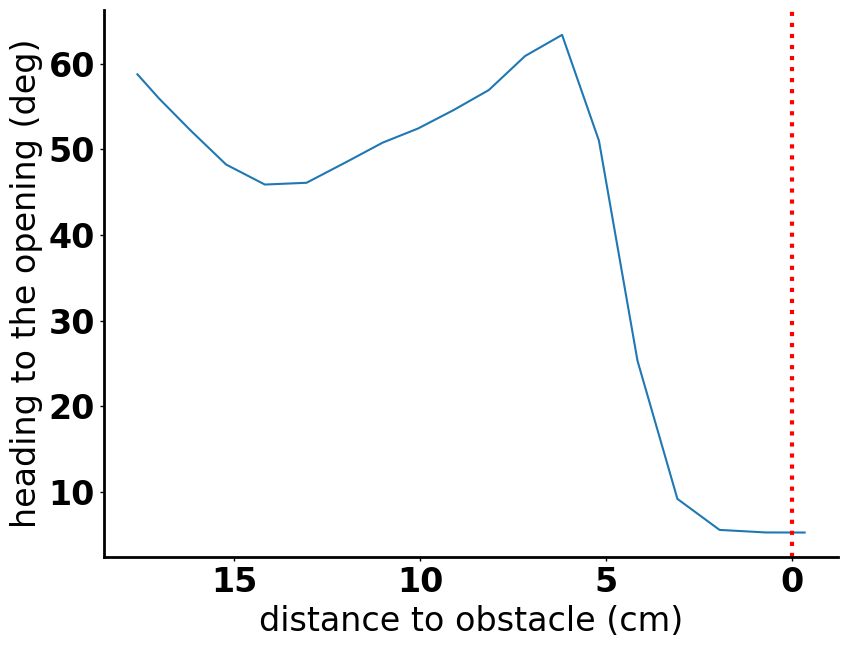

In [281]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_heading_to_opening_single_first_occurence.pdf',dpi = 300, transparent=True)
    

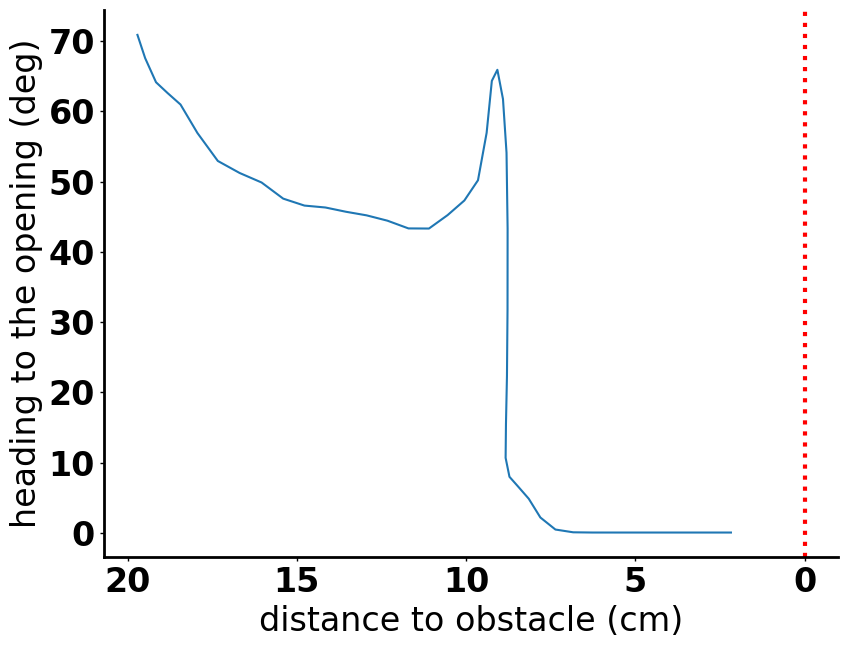

In [515]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_heading_to_opening_single.pdf',dpi = 300, transparent=True)

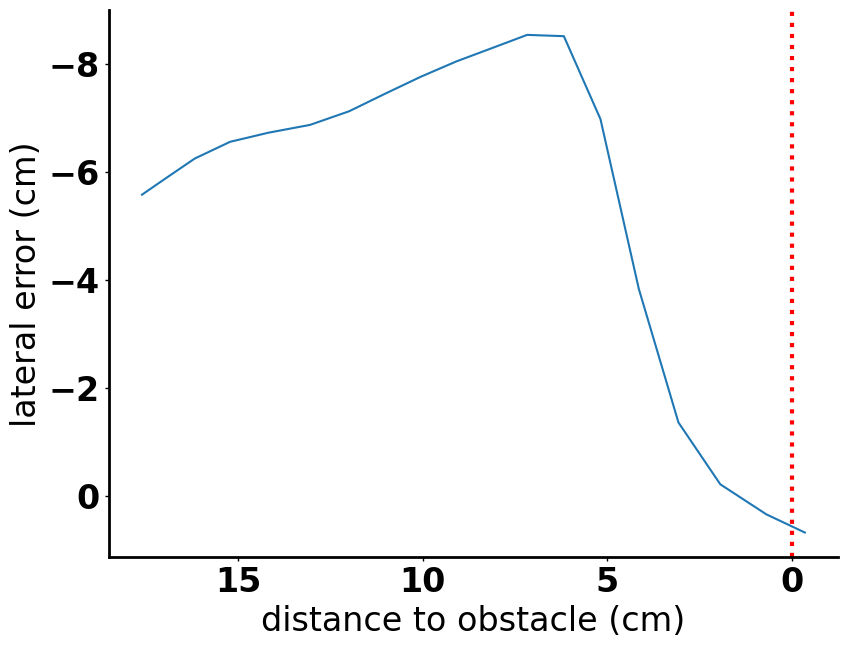

In [280]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_lateral_error_single_first_occurance.pdf',dpi = 300, transparent=True)
    

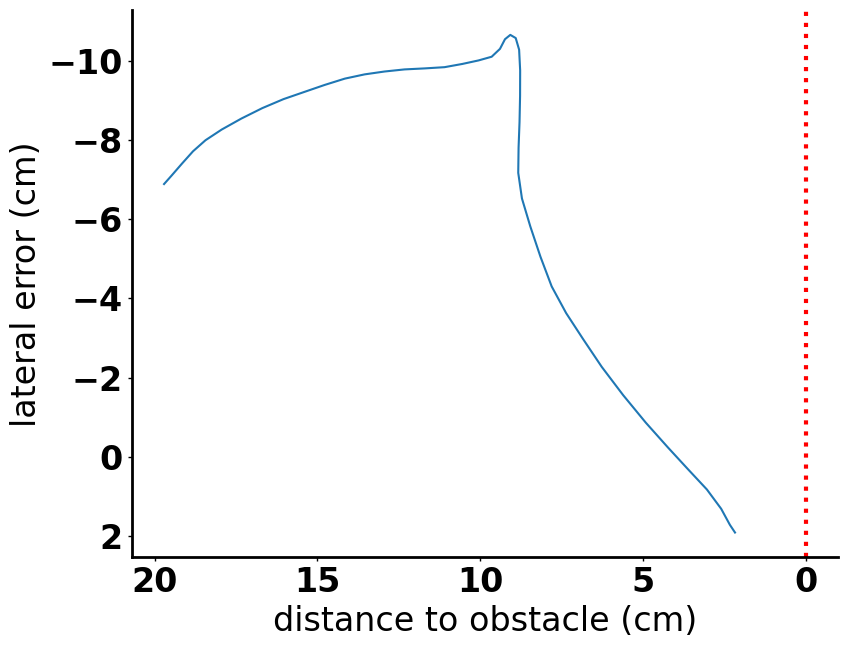

In [525]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_light.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(x1),smooth(y1))
ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_light_lateral_error_single.pdf',dpi = 300, transparent=True)

Single Trial dark

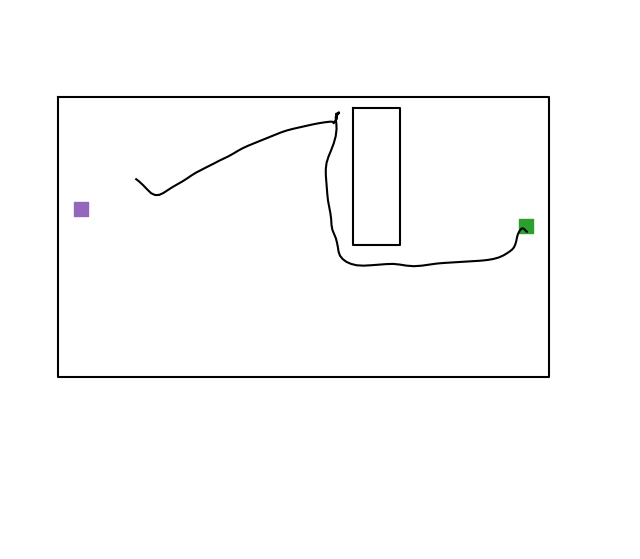

In [530]:
data = long_nostart[(long_nostart.obstacle_cluster == 1)&(long_nostart.task == 'oadark')&(long_nostart.turn_to_obstacle == 'towards')]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
sample_dark = data.sample(1)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42  
for ind,row in sample_dark.iterrows():
    fig,ax = plt.subplots(1,1,figsize=(8,7))
    
    #ax[1].set_xlim(20,0)
    


    ax.set_xticks([])
    ax.set_yticks([])
  
    #ax[2].invert_xaxis()
    plot_arena(sample_dark,ax)
    ob_x,ob_y = plot_orginal_obstacle(sample_dark,ax,int(row.obstacle_cluster))


    trial_df = data.loc[[ind]]

    for ind,row in trial_df.iterrows():
        x, y = correct_trace(row,ob_x,ob_y)
        #ax[1].set_title('head_corner_angle_velocity_at_head_turn head '+ str(row.head_corner_angle_velocity_at_head_turn) + ' '+row.task )
        #ax[1].set_ylim(-12,2)
        ob_ind = int(row.obstacle_ind)
        x1 = x
        y1 = y
        ax.plot(x1,y1,color = 'black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_trace.pdf',dpi = 300, transparent=True)

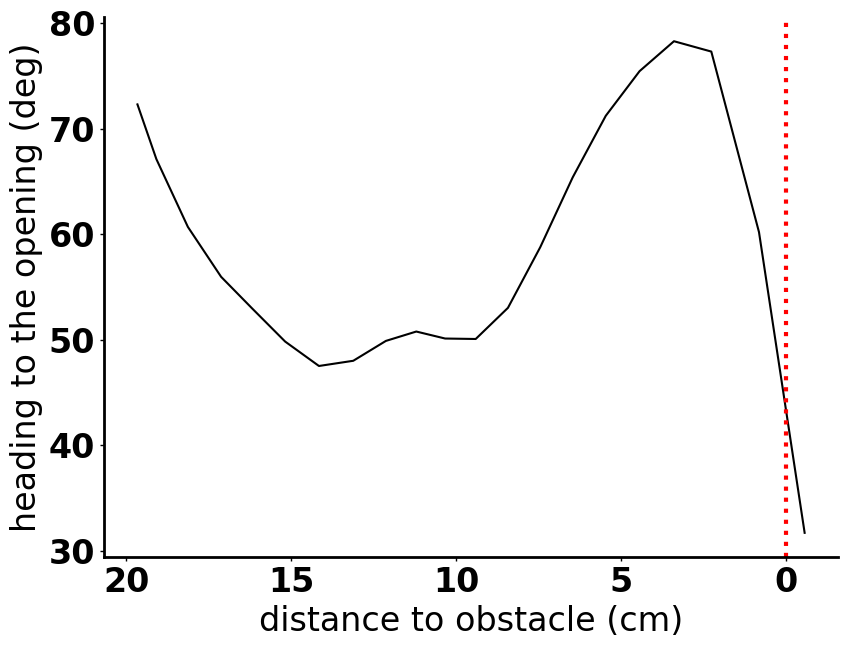

In [283]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_heading_to_opening_single_first_occurence.pdf',dpi = 300, transparent=True)

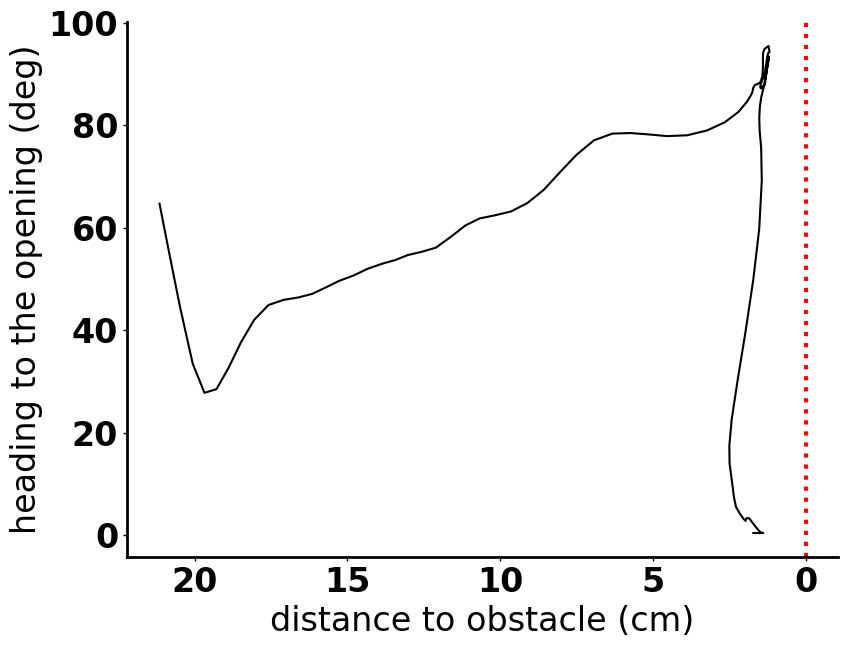

In [531]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_heading_to_opening_single.pdf',dpi = 300, transparent=True)

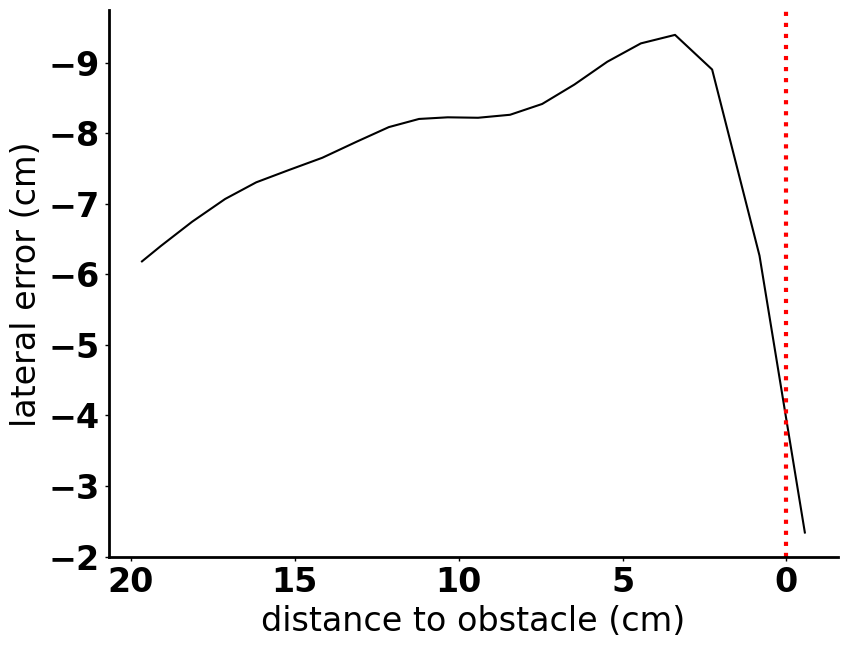

In [285]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x[first_occurrence_indices(np.round(x))]
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y[first_occurrence_indices(np.round(x))]
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_lateral_error_single_first_occurance.pdf',dpi = 300, transparent=True)

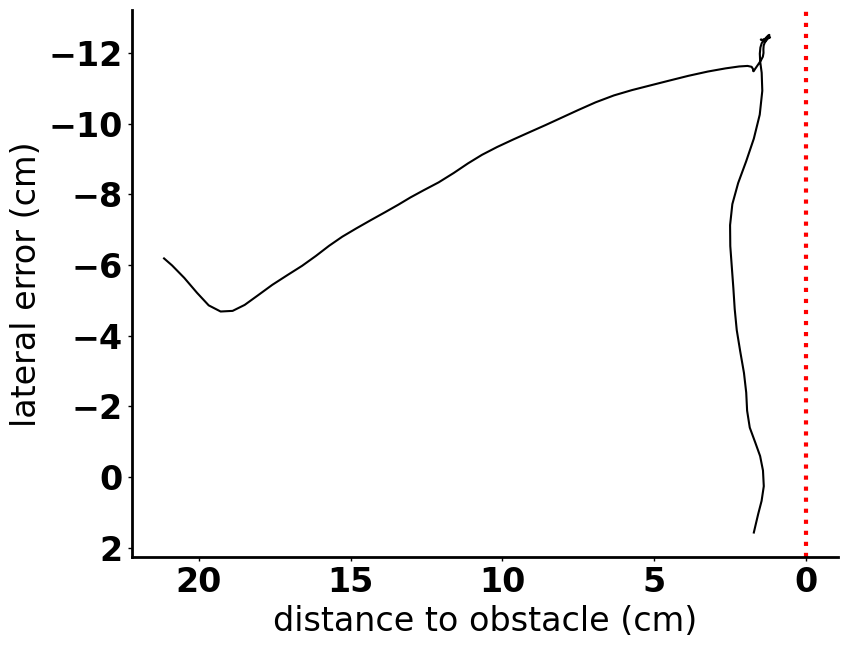

In [532]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['lateral_error'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('lateral error (cm)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.invert_yaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_dark_lateral_error.pdf',dpi = 300, transparent=True)

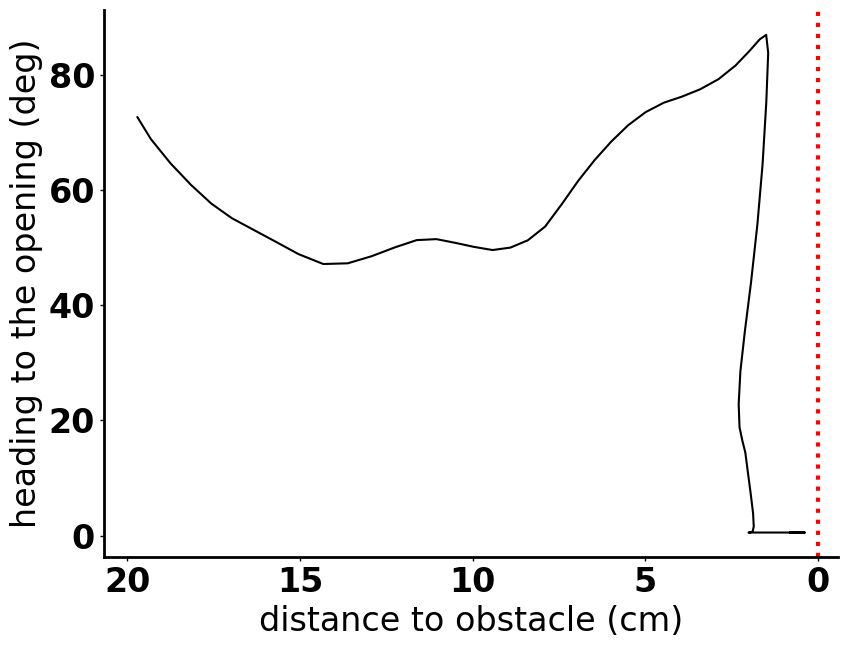

In [287]:
fig,ax = plt.subplots(1,1,figsize=(9,7), layout = 'tight')
for ind,row in sample_dark.iterrows():
    x = row['ts_distance_from_edge'][:int(row['obstacle_ind'])].astype(float)
    x1 = x
    y = row['ts_zero_out_angle_to_corner'][:int(row['obstacle_ind'])].astype(float)
    y1 = y
ax.set_xlabel('distance to obstacle (cm)')
ax.set_ylabel('heading to the opening (deg)')
ax.plot(smooth(x1),smooth(y1),c = 'black')
ax.invert_xaxis()
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
ax.spines[['right', 'top']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2)

Long first occurance

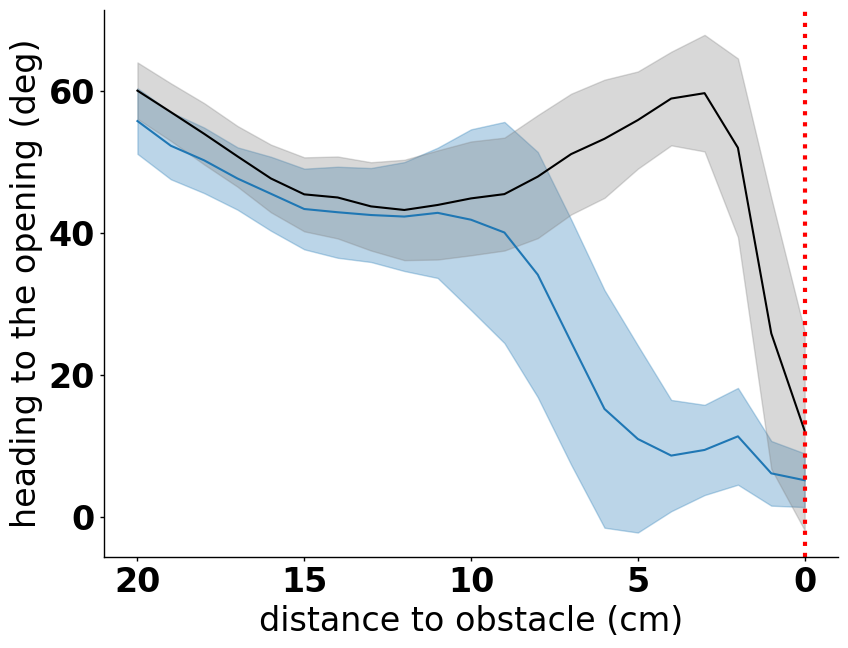

In [541]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (9,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
#ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
#fig.suptitle('joint')
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_population_heading_to_opening_first_occurance.pdf',dpi = 300, transparent=True)

In [542]:
light_angle_median

array([55.83299613, 52.35528547, 50.29676118, 47.73405614, 45.59163768,
       43.44196017, 42.9866138 , 42.59477413, 42.3780223 , 42.90139878,
       41.93077526, 40.13215297, 34.19558321, 24.69685741, 15.28089513,
       11.04587665,  8.70764666,  9.50315219, 11.42126127,  6.20726617,
        5.23498415])

Text(0.5, 0.98, 'long')

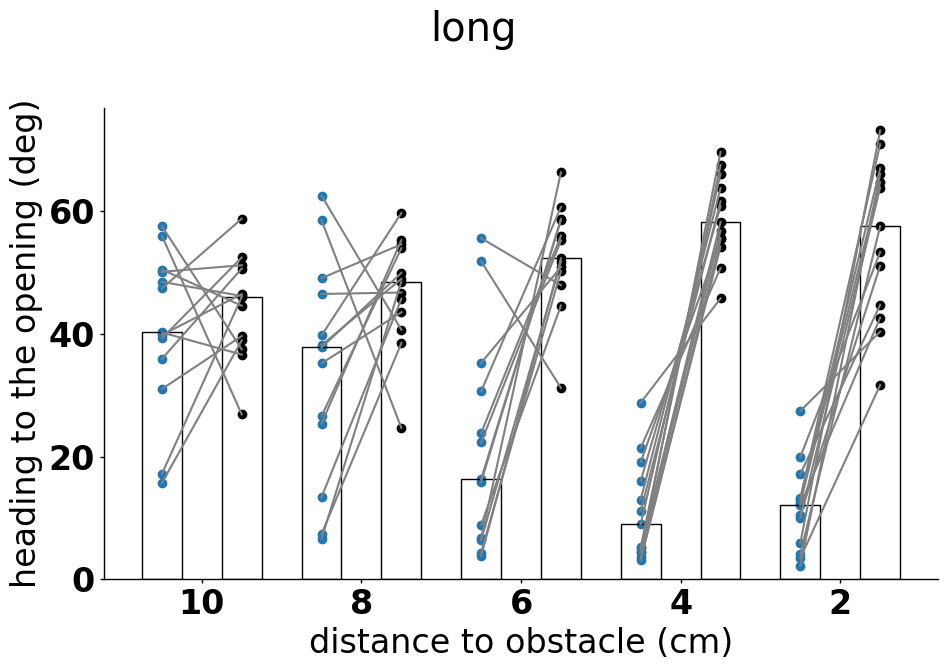

In [297]:
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,12],dark_medians[:,12]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,14],dark_medians[:,14]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,16],dark_medians[:,16]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.bar(8,np.nanmedian(light_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
ax.bar(9,np.nanmedian(dark_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],8),np.full(dark_medians.shape[0],9)),(light_medians[:,18],dark_medians[:,18]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('long')


In [300]:
np.nanstd(light_medians[:,10])

12.733471995423946

Text(0.5, 0, 'distance to obstacle (cm)')

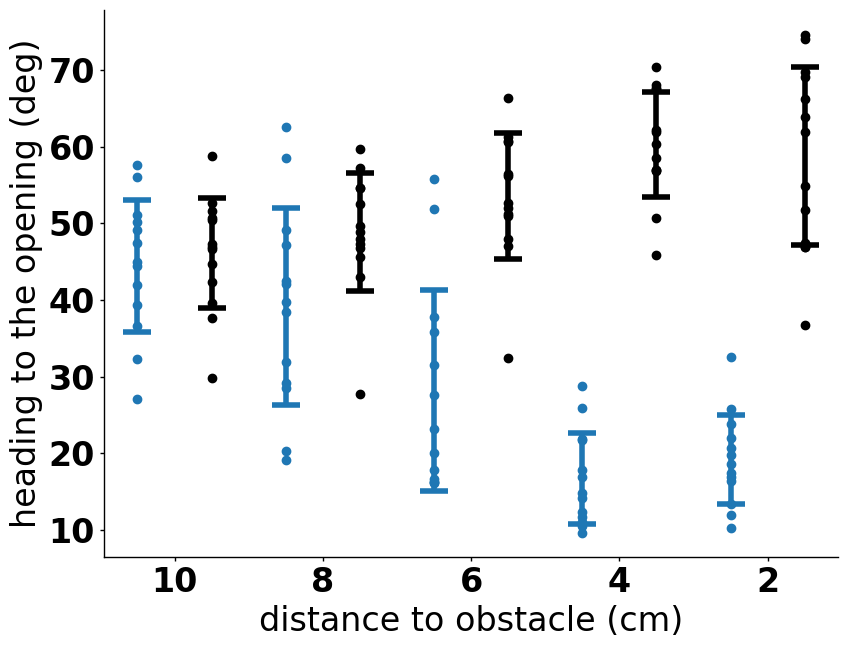

In [464]:
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
fig,ax = plt.subplots(layout = 'tight',figsize = (9,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])



ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
light_std= np.nanstd(light_medians[:,10])
dark_std= np.nanstd(dark_medians[:,10])
ax.errorbar([0],[np.nanmean(light_medians[:,10])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([1],[np.nanmean(dark_medians[:,10])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)
#ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
#ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
light_std= np.nanstd(light_medians[:,12])
dark_std= np.nanstd(dark_medians[:,12])
ax.errorbar([2],[np.nanmean(light_medians[:,12])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([3],[np.nanmean(dark_medians[:,12])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
light_std= np.nanstd(light_medians[:,14])
dark_std= np.nanstd(dark_medians[:,14])
ax.errorbar([4],[np.nanmean(light_medians[:,14])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([5],[np.nanmean(dark_medians[:,14])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
light_std= np.nanstd(light_medians[:,16])
dark_std= np.nanstd(dark_medians[:,16])
ax.errorbar([6],[np.nanmean(light_medians[:,16])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([7],[np.nanmean(dark_medians[:,16])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
light_std= np.nanstd(light_medians[:,18])
dark_std= np.nanstd(dark_medians[:,18])
ax.errorbar([8],[np.nanmean(light_medians[:,18])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([9],[np.nanmean(dark_medians[:,18])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)


ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')


In [ ]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(0, 100, 5)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=0))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=100))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=0))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=100))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=0))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=100))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=0))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=100))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')
ax.set_ylim(0,.14)
ax.set_xlim(0,95)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))

In [501]:
len(dark_medians)

13

In [465]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat,i)

F_onewayResult(statistic=3.3471034419370698, pvalue=0.07977461586949013) 20
F_onewayResult(statistic=5.822134746956699, pvalue=0.02382609323526618) 19
F_onewayResult(statistic=5.461531042746096, pvalue=0.028113731207279273) 18
F_onewayResult(statistic=5.519747119861658, pvalue=0.027366895042811815) 17
F_onewayResult(statistic=3.134398275179896, pvalue=0.08935990878063757) 16
F_onewayResult(statistic=2.1382154961244493, pvalue=0.15664127755763427) 15
F_onewayResult(statistic=1.4516414054787132, pvalue=0.24001154402314437) 14
F_onewayResult(statistic=0.5424828946512812, pvalue=0.46854451984732903) 13
F_onewayResult(statistic=0.22541475855087126, pvalue=0.6392366856314647) 12
F_onewayResult(statistic=0.3365329543538075, pvalue=0.5672444204023145) 11
F_onewayResult(statistic=0.25170670217531765, pvalue=0.6204473447585588) 10
F_onewayResult(statistic=1.5488709854342908, pvalue=0.22531909409629997) 9
F_onewayResult(statistic=5.081532032849492, pvalue=0.033584782399987946) 8
F_onewayResult(st

In [ ]:
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_numpy())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=10))]
    counts, bins = np.histogram(ani_light_dists, bins=11)
    light_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')   

In [478]:
xnew

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175])

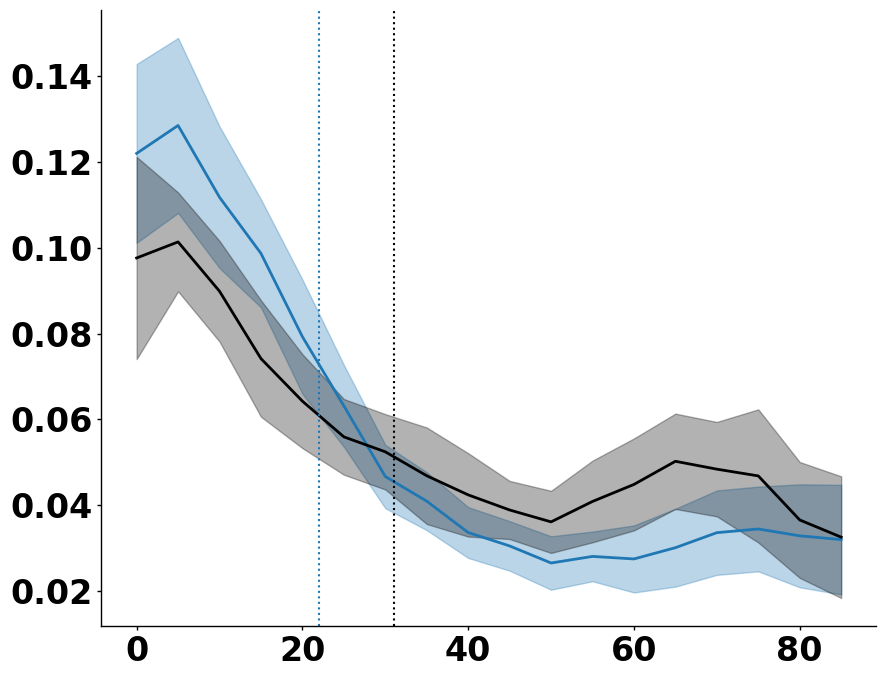

In [424]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(0, 90, 5)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=1))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=0))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=90))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=1))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=0))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=90))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=1))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=0))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=90))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=1))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=0))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=90))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')


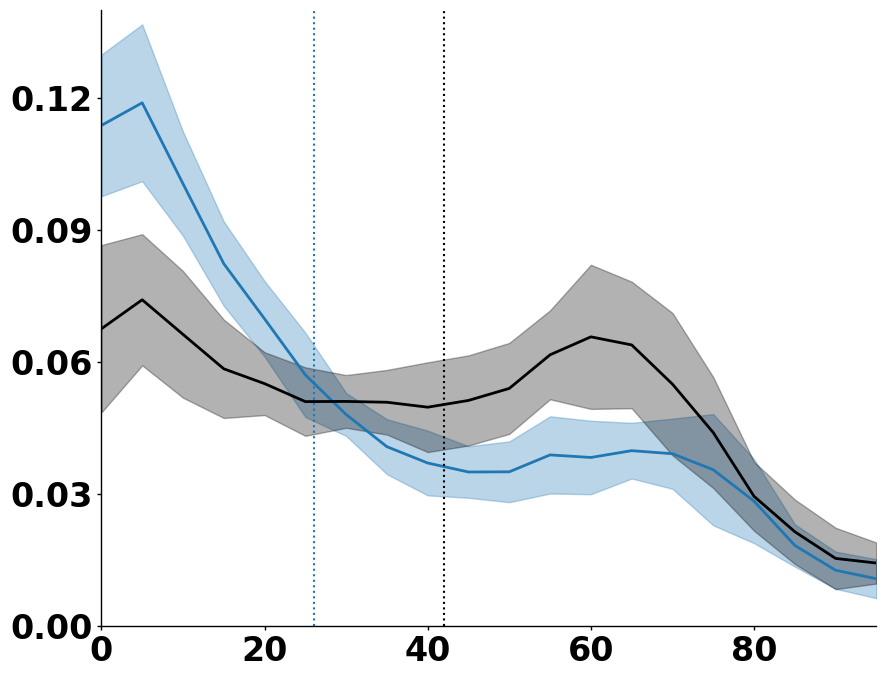

In [534]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(0, 100, 5)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=0))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=100))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=0))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=100))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=0))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=100))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=8)&(row.ts_distance_from_edge>=2))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=0))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=100))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')
ax.set_ylim(0,.14)
ax.set_xlim(0,95)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))

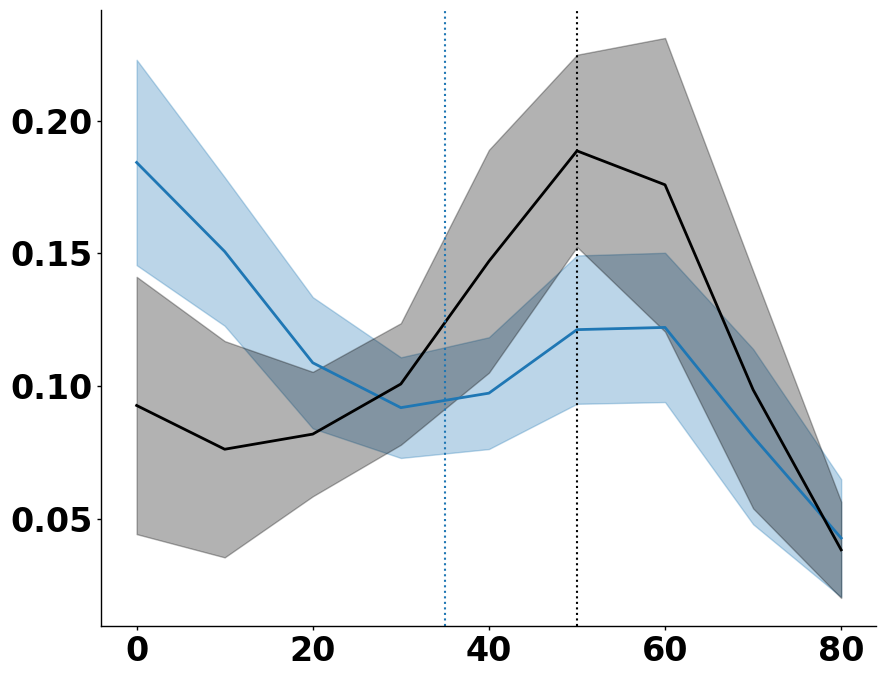

In [436]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(0, 90, 10)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=10)&(row.ts_distance_from_edge>=5))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=0))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=90))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=10)&(row.ts_distance_from_edge>=5))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=0))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=90))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=10)&(row.ts_distance_from_edge>=5))
    angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=0))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=90))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=10)&(row.ts_distance_from_edge>=5))
        angs = np.round(row.ts_angle_to_corner[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=0))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=90))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')

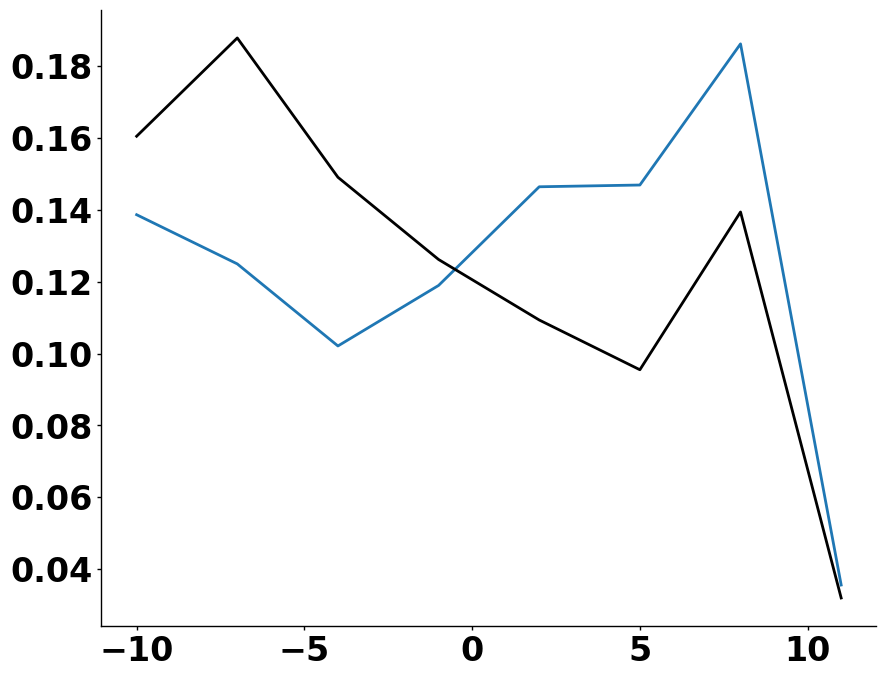

In [433]:
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(-10, 12, 3)
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.task == 'oa']
occup_arr = []
for ind, row in data.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.lateral_error[thresh].astype(float))
    occup_arr.append(angs)
occup_arr = np.asarray(flatten_list_of_arrays(occup_arr))
occup_arr = occup_arr[np.where((occup_arr>=-10))]
occup_arr = occup_arr[np.where((occup_arr<=10))]

light_counts, light_bins = np.histogram(occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')

data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.task == 'oadark']
occup_arr = []
for ind, row in data.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=5)&(row.ts_distance_from_edge>=2))
    angs = np.round(row.lateral_error[thresh].astype(float))
    occup_arr.append(angs)
occup_arr = np.asarray(flatten_list_of_arrays(occup_arr))
occup_arr = occup_arr[np.where((occup_arr>=-10))]
occup_arr = occup_arr[np.where((occup_arr<=10))]

dark_counts, dark_bins = np.histogram(occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')

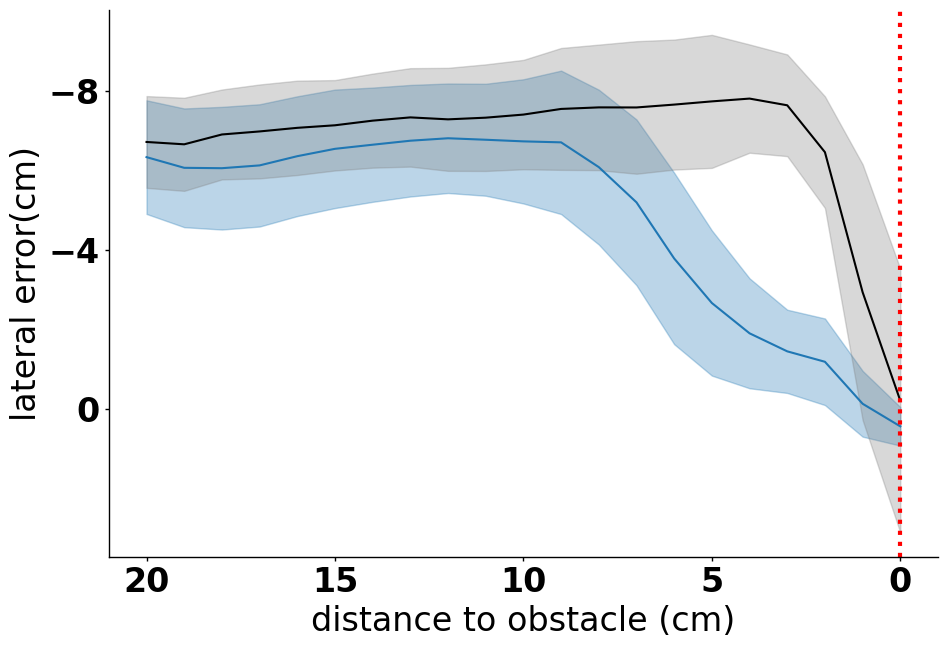

In [490]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
#ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_population_lateral_error_first_occurance.pdf',dpi = 300, transparent=True)


In [495]:
data.animal.unique()

array(['J701LT', 'J701RT', 'J701NN', 'J701RN', 'G8CK1RT', 'G8CK1LT',
       'G8CK1TT', 'G8CK1LN', 'G8CKRT', 'G8CKLT', 'G8CKTT', 'G8CKRN',
       'G8CKLN', 'J704RT', 'J704NN', 'J704LT', 'J704LN'], dtype=object)

Text(0.5, 0, 'distance to obstacle (cm)')

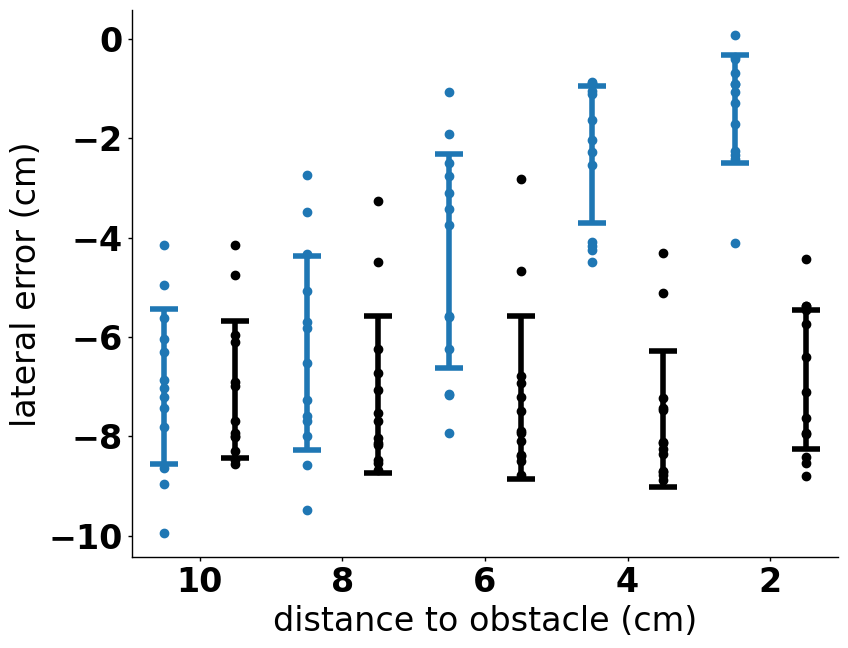

In [491]:
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
fig,ax = plt.subplots(layout = 'tight',figsize = (9,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])



ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
light_std= np.nanstd(light_medians[:,10])
dark_std= np.nanstd(dark_medians[:,10])
ax.errorbar([0],[np.nanmean(light_medians[:,10])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([1],[np.nanmean(dark_medians[:,10])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)
#ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
#ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:, 10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
light_std= np.nanstd(light_medians[:,12])
dark_std= np.nanstd(dark_medians[:,12])
ax.errorbar([2],[np.nanmean(light_medians[:,12])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([3],[np.nanmean(dark_medians[:,12])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
light_std= np.nanstd(light_medians[:,14])
dark_std= np.nanstd(dark_medians[:,14])
ax.errorbar([4],[np.nanmean(light_medians[:,14])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([5],[np.nanmean(dark_medians[:,14])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
light_std= np.nanstd(light_medians[:,16])
dark_std= np.nanstd(dark_medians[:,16])
ax.errorbar([6],[np.nanmean(light_medians[:,16])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([7],[np.nanmean(dark_medians[:,16])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
light_std= np.nanstd(light_medians[:,18])
dark_std= np.nanstd(dark_medians[:,18])
ax.errorbar([8],[np.nanmean(light_medians[:,18])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([9],[np.nanmean(dark_medians[:,18])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)


ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')

In [492]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat,i)

F_onewayResult(statistic=0.2833664260165376, pvalue=0.5993973089051872) 20
F_onewayResult(statistic=0.4148659628809633, pvalue=0.5256184042000546) 19
F_onewayResult(statistic=0.45529313230438473, pvalue=0.5062806760142807) 18
F_onewayResult(statistic=0.30491689147677553, pvalue=0.5859223676404658) 17
F_onewayResult(statistic=0.10175894915599724, pvalue=0.7524887768446236) 16
F_onewayResult(statistic=0.04154036247575387, pvalue=0.8402167804949153) 15
F_onewayResult(statistic=0.005796596304149897, pvalue=0.9399425140366658) 14
F_onewayResult(statistic=0.01571801504945646, pvalue=0.9012737298860516) 13
F_onewayResult(statistic=0.01018278318975444, pvalue=0.9204603655709434) 12
F_onewayResult(statistic=0.003576040572212558, pvalue=0.9528100913002698) 11
F_onewayResult(statistic=0.012448513480039067, pvalue=0.9120899406503541) 10
F_onewayResult(statistic=0.25893075341781774, pvalue=0.6155020384758464) 9
F_onewayResult(statistic=1.306194455655698, pvalue=0.2643581209418266) 8
F_onewayResult(

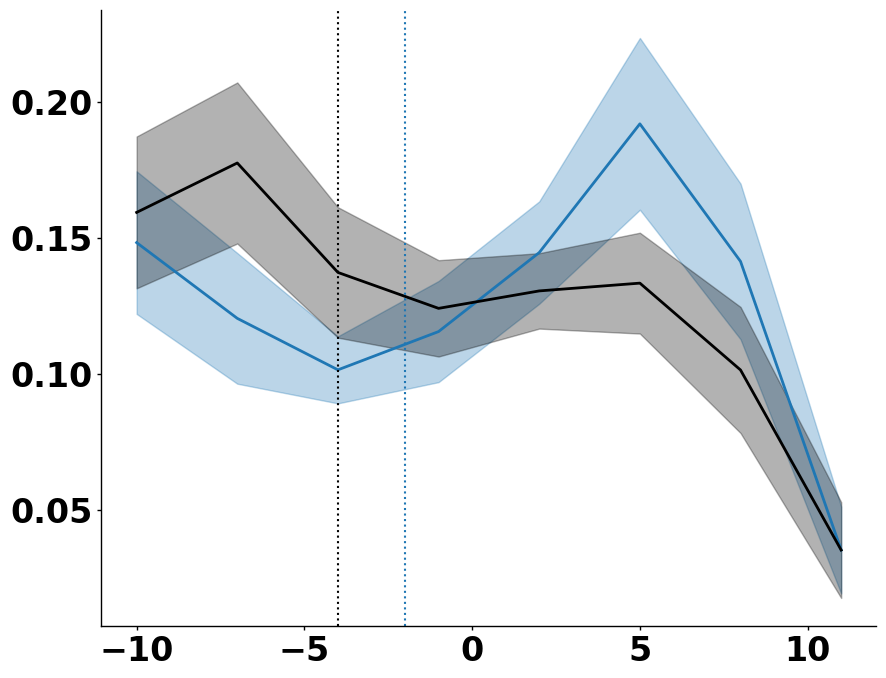

In [540]:
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
light = data[data.task == 'oa']
dark = data[data.task == 'oadark']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
xnew =  np.arange(-10, 12, 3)
light_occup_arr = []
dark_occup_arr = []

for ind, row in light.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=6)&(row.ts_distance_from_edge>=1))
    angs = np.round(row.lateral_error[thresh].astype(float))
    light_occup_arr.append(angs)
light_occup_arr = np.asarray(flatten_list_of_arrays(light_occup_arr))
light_occup_arr = light_occup_arr[np.where((light_occup_arr>=-10))]
light_occup_arr = light_occup_arr[np.where((light_occup_arr<=10))]
light_counts, light_bins = np.histogram(light_occup_arr, bins=len(xnew))
ax.plot(xnew, (light_counts/sum(light_counts)), 'b-', linewidth=2, label='Line',color='tab:blue')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    light_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=6)&(row.ts_distance_from_edge>=1))
        angs = np.round(row.lateral_error[thresh].astype(float))
        light_ani_array.append(angs)
    light_ani_array = np.asarray(flatten_list_of_arrays(light_ani_array))
    light_ani_array = light_ani_array[np.where((light_ani_array>=-10))]
    light_ani_array = light_ani_array[np.where((light_ani_array<=6))]
    counts, bins = np.histogram(light_ani_array, bins=len(xnew))
    light_prob.append(counts/sum(counts))
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')

for ind, row in dark.iterrows():
    thresh = np.where((row.ts_distance_from_edge<=6)&(row.ts_distance_from_edge>=1))
    angs = np.round(row.lateral_error[thresh].astype(float))
    dark_occup_arr.append(angs)
dark_occup_arr = np.asarray(flatten_list_of_arrays(dark_occup_arr))
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr>=-10))]
dark_occup_arr = dark_occup_arr[np.where((dark_occup_arr<=10))]
dark_counts, dark_bins = np.histogram(dark_occup_arr, bins=len(xnew))
ax.plot(xnew, (dark_counts/sum(dark_counts)), 'b-', linewidth=2, label='Line',color='black')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    dark_ani_array = []
    for ind,row in ani_df.iterrows():
        thresh = np.where((row.ts_distance_from_edge<=6)&(row.ts_distance_from_edge>=1))
        angs = np.round(row.lateral_error[thresh].astype(float))
        dark_ani_array.append(angs)
    dark_ani_array = np.asarray(flatten_list_of_arrays(dark_ani_array))
    dark_ani_array = dark_ani_array[np.where((dark_ani_array>=-10))]
    dark_ani_array = dark_ani_array[np.where((dark_ani_array<=10))]
    counts, bins = np.histogram(dark_ani_array, bins=len(xnew))
    dark_prob.append(counts/sum(counts))
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')  

ax.axvline(np.nanmedian(light_occup_arr), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_occup_arr), color='black', ls=':')

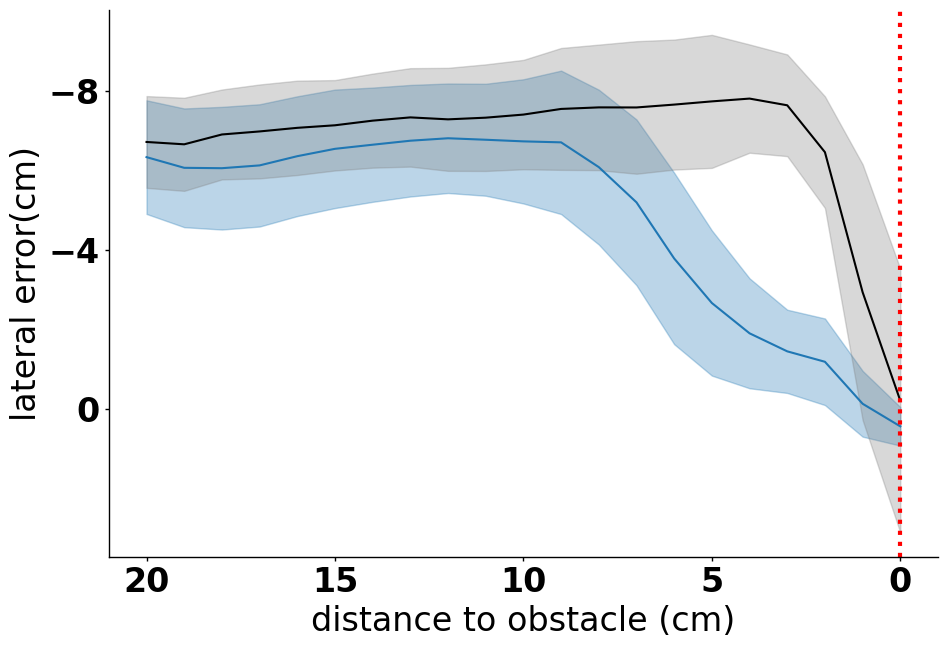

In [453]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':',linewidth = 3)
#ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
#ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_population_lateral_error_first_occurance.pdf',dpi = 300, transparent=True)


Text(0.5, 0, 'distance to obstacle (cm)')

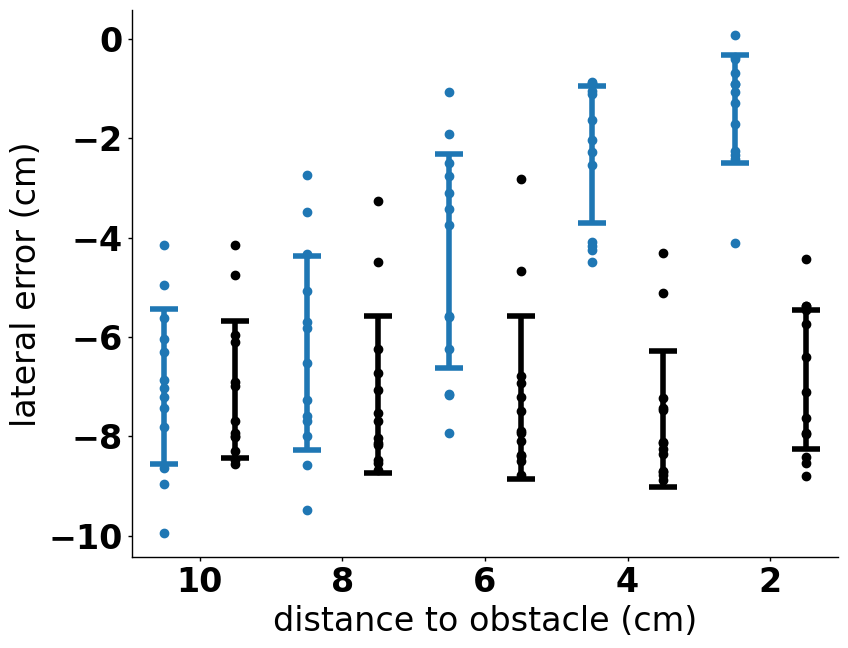

In [456]:
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
fig,ax = plt.subplots(layout = 'tight',figsize = (9,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])



ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
light_std= np.nanstd(light_medians[:,10])
dark_std= np.nanstd(dark_medians[:,10])
ax.errorbar([0],[np.nanmean(light_medians[:,10])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([1],[np.nanmean(dark_medians[:,10])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)
#ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
#ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
light_std= np.nanstd(light_medians[:,12])
dark_std= np.nanstd(dark_medians[:,12])
ax.errorbar([2],[np.nanmean(light_medians[:,12])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([3],[np.nanmean(dark_medians[:,12])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
light_std= np.nanstd(light_medians[:,14])
dark_std= np.nanstd(dark_medians[:,14])
ax.errorbar([4],[np.nanmean(light_medians[:,14])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([5],[np.nanmean(dark_medians[:,14])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
light_std= np.nanstd(light_medians[:,16])
dark_std= np.nanstd(dark_medians[:,16])
ax.errorbar([6],[np.nanmean(light_medians[:,16])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([7],[np.nanmean(dark_medians[:,16])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
light_std= np.nanstd(light_medians[:,18])
dark_std= np.nanstd(dark_medians[:,18])
ax.errorbar([8],[np.nanmean(light_medians[:,18])] , yerr=[light_std], ls='none' ,color='tab:blue',elinewidth=4, capsize=10,capthick=4)
ax.errorbar([9],[np.nanmean(dark_medians[:,18])] , yerr=[dark_std], ls='none' ,color='black',elinewidth=4, capsize=10,capthick=4)


ax.set_ylabel('lateral error (cm)')
ax.set_xlabel('distance to obstacle (cm)')

In [458]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat,i)


F_onewayResult(statistic=0.2833664260165376, pvalue=0.5993973089051872) 20
F_onewayResult(statistic=0.4148659628809633, pvalue=0.5256184042000546) 19
F_onewayResult(statistic=0.45529313230438473, pvalue=0.5062806760142807) 18
F_onewayResult(statistic=0.30491689147677553, pvalue=0.5859223676404658) 17
F_onewayResult(statistic=0.10175894915599724, pvalue=0.7524887768446236) 16
F_onewayResult(statistic=0.04154036247575387, pvalue=0.8402167804949153) 15
F_onewayResult(statistic=0.005796596304149897, pvalue=0.9399425140366658) 14
F_onewayResult(statistic=0.01571801504945646, pvalue=0.9012737298860516) 13
F_onewayResult(statistic=0.01018278318975444, pvalue=0.9204603655709434) 12
F_onewayResult(statistic=0.003576040572212558, pvalue=0.9528100913002698) 11
F_onewayResult(statistic=0.012448513480039067, pvalue=0.9120899406503541) 10
F_onewayResult(statistic=0.25893075341781774, pvalue=0.6155020384758464) 9
F_onewayResult(statistic=1.306194455655698, pvalue=0.2643581209418266) 8
F_onewayResult(

Text(0.5, 0.98, 'joint')

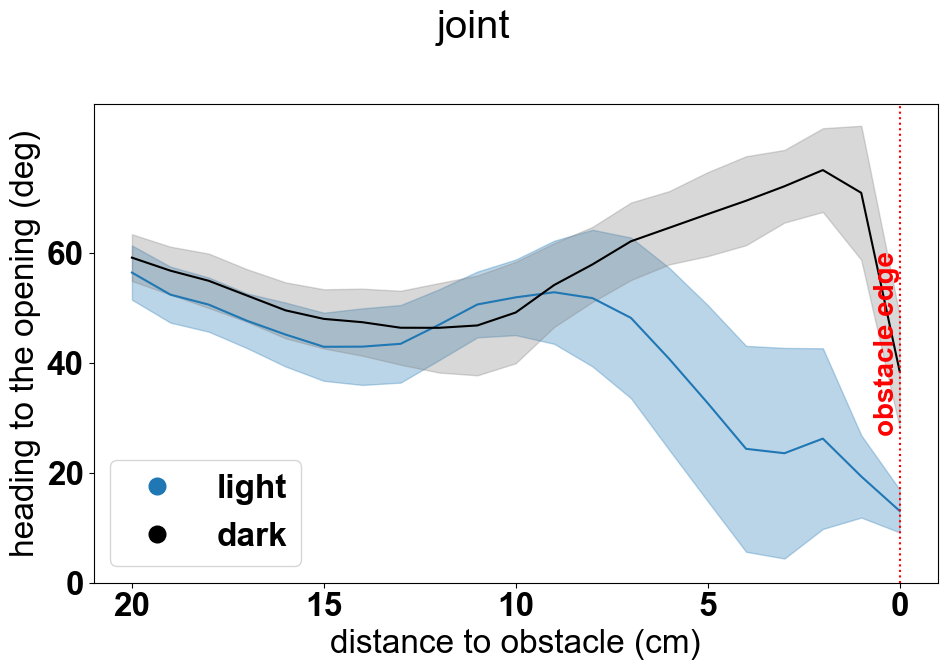

In [31]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart,short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('joint')

In [51]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([long_nostart,short_nostart])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)


Text(0.5, 0.98, 'joint')

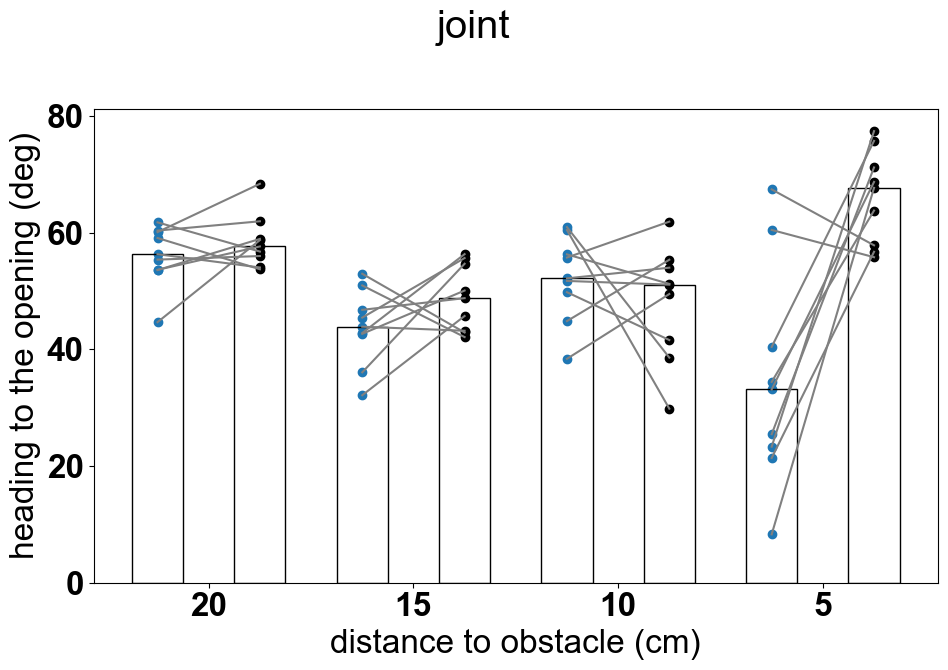

In [52]:
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('joint')

Text(0.5, 0.98, 'joint')

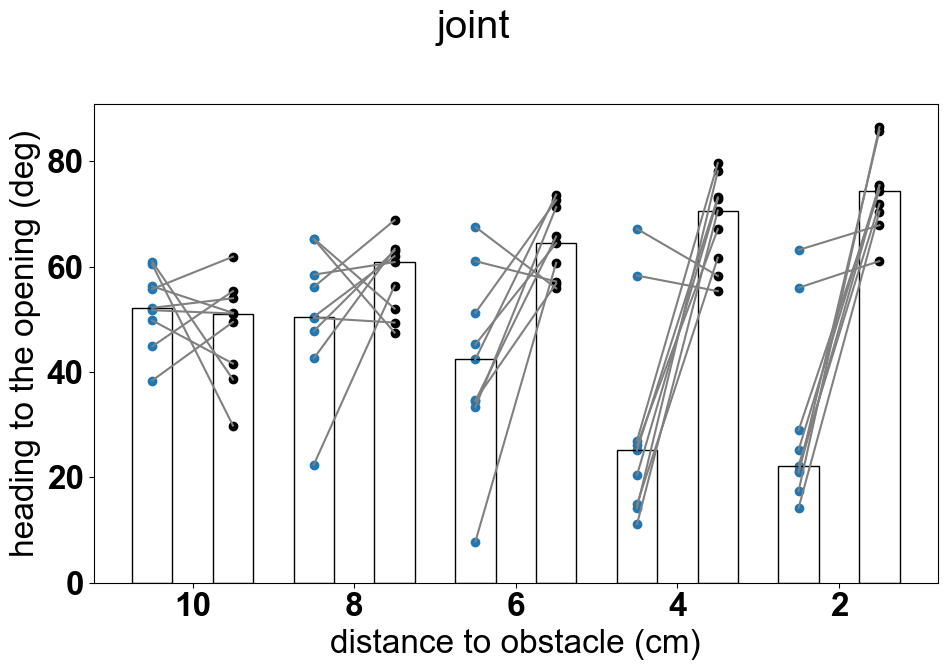

In [53]:
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,12],dark_medians[:,12]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,14],dark_medians[:,14]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,16],dark_medians[:,16]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.bar(8,np.nanmedian(light_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
ax.bar(9,np.nanmedian(dark_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],8),np.full(dark_medians.shape[0],9)),(light_medians[:,18],dark_medians[:,18]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('joint')



In [131]:
f_oneway(dark_medians[:,1],light_medians[:,1])

F_onewayResult(statistic=4.878235802044109, pvalue=0.042131356934708014)

In [54]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat,i)



F_onewayResult(statistic=1.0531404232753245, pvalue=0.3200506526112995) 20
F_onewayResult(statistic=3.56558999040223, pvalue=0.07725863751235792) 19
F_onewayResult(statistic=2.5890470296918595, pvalue=0.12715563026795643) 18
F_onewayResult(statistic=4.310156625692577, pvalue=0.05436246406283614) 17
F_onewayResult(statistic=3.3783383619141434, pvalue=0.08469837945105797) 16
F_onewayResult(statistic=3.0745020920894772, pvalue=0.09866223408835402) 15
F_onewayResult(statistic=1.5323938077769228, pvalue=0.23361135639858002) 14
F_onewayResult(statistic=0.42555065300497874, pvalue=0.5234425427933783) 13
F_onewayResult(statistic=0.1511554023672835, pvalue=0.7025586973751916) 12
F_onewayResult(statistic=1.6858845710765809, pvalue=0.21254825118891213) 11
F_onewayResult(statistic=1.03824543126862, pvalue=0.32339081686113835) 10
F_onewayResult(statistic=0.06483570674251628, pvalue=0.8022537404411956) 9
F_onewayResult(statistic=2.0557174955486506, pvalue=0.17088962987846387) 8
F_onewayResult(statis

Long trials angle to corner 

Text(0.5, 0.98, 'long')

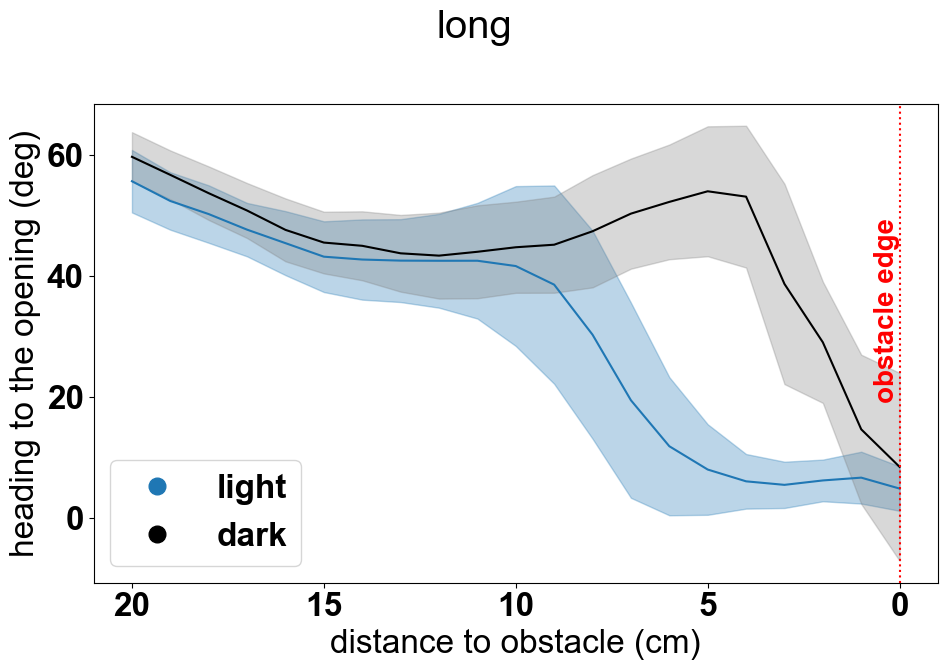

In [32]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long')

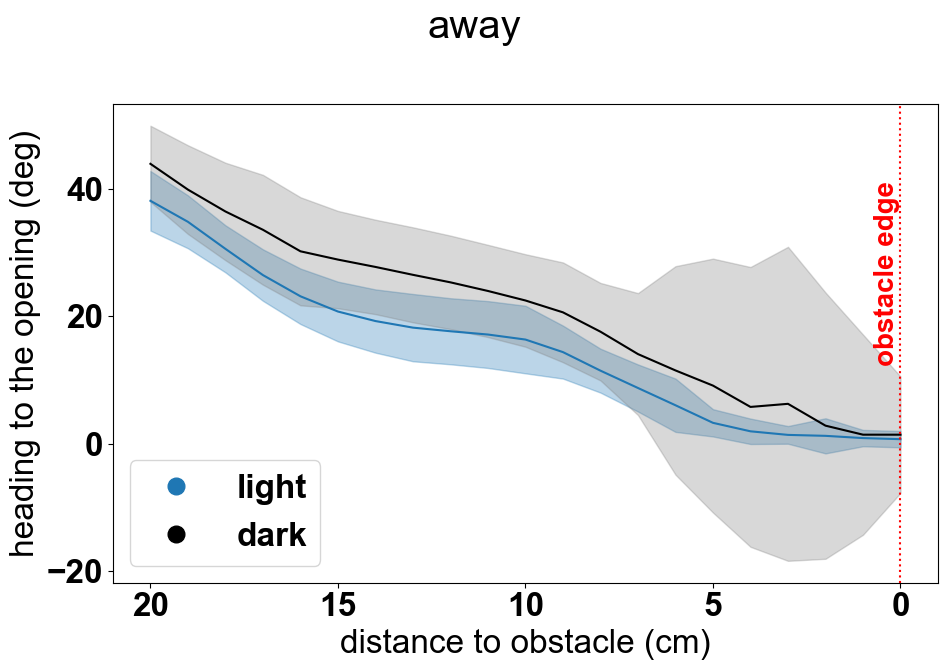

In [62]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'away']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

#for i in list(range(light_medians.shape[1])):
#    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
#    light_sd.append(sd)
#light_sd = np.asarray(light_sd)
#
#for i in list(range(dark_medians.shape[1])):
#    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
#    dark_sd.append(sd)
#dark_sd = np.asarray(dark_sd)
#
            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
#ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('away')
fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_heading_away.pdf',dpi = 300, transparent=True)

Text(0.5, 0.98, 'long towards first occurance')

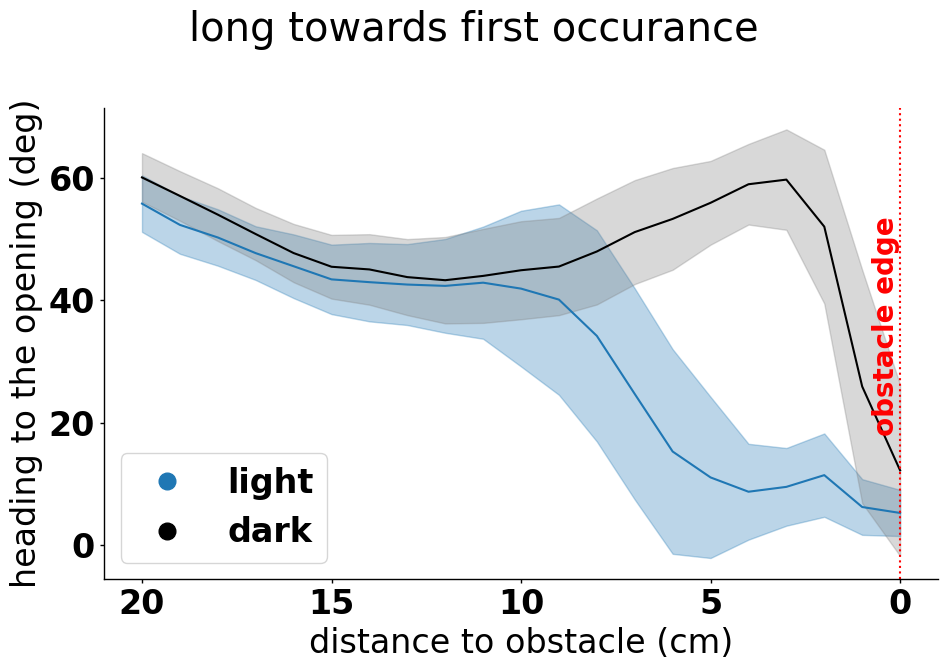

In [163]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

#for i in list(range(light_medians.shape[1])):
#    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
#    light_sd.append(sd)
#light_sd = np.asarray(light_sd)
#
#for i in list(range(dark_medians.shape[1])):
#    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
#    dark_sd.append(sd)
#dark_sd = np.asarray(dark_sd)
#
            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long towards first occurance')
#fig.savefig(r'd:\obstacle_avoidance\figures\obstacle_avoidance_paper\figure_three\long_heading_towards.pdf',dpi = 300, transparent=True)

Text(0.5, 0.98, 'long towards first occurance')

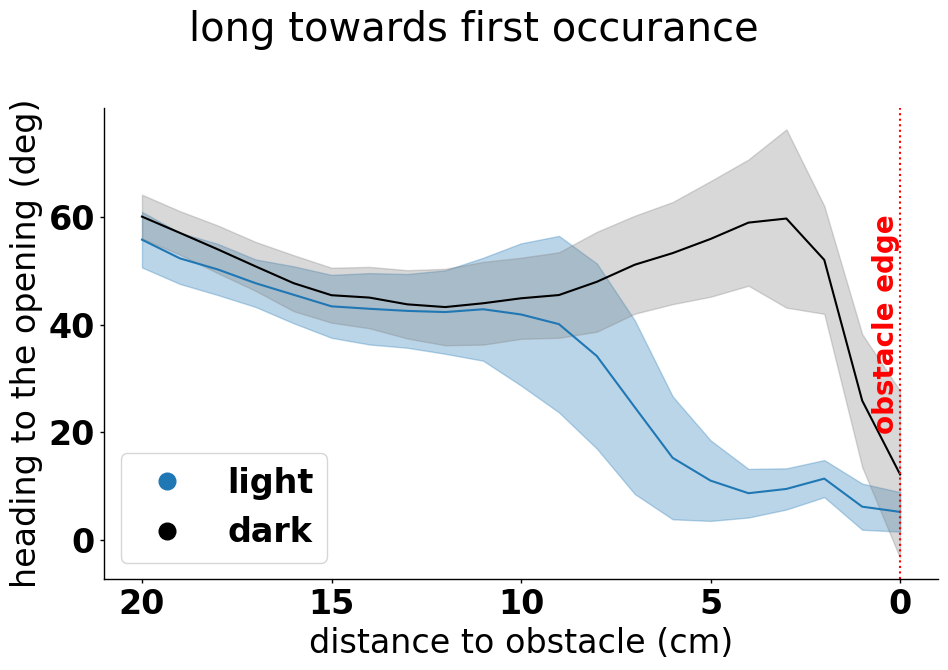

In [164]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

#for i in list(range(light_medians.shape[1])):
#    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
#    light_sd.append(sd)
#light_sd = np.asarray(light_sd)
#
#for i in list(range(dark_medians.shape[1])):
#    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
#    dark_sd.append(sd)
#dark_sd = np.asarray(dark_sd)
#
            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long towards first occurance')

Text(0.5, 0.98, 'long (last occurance)')

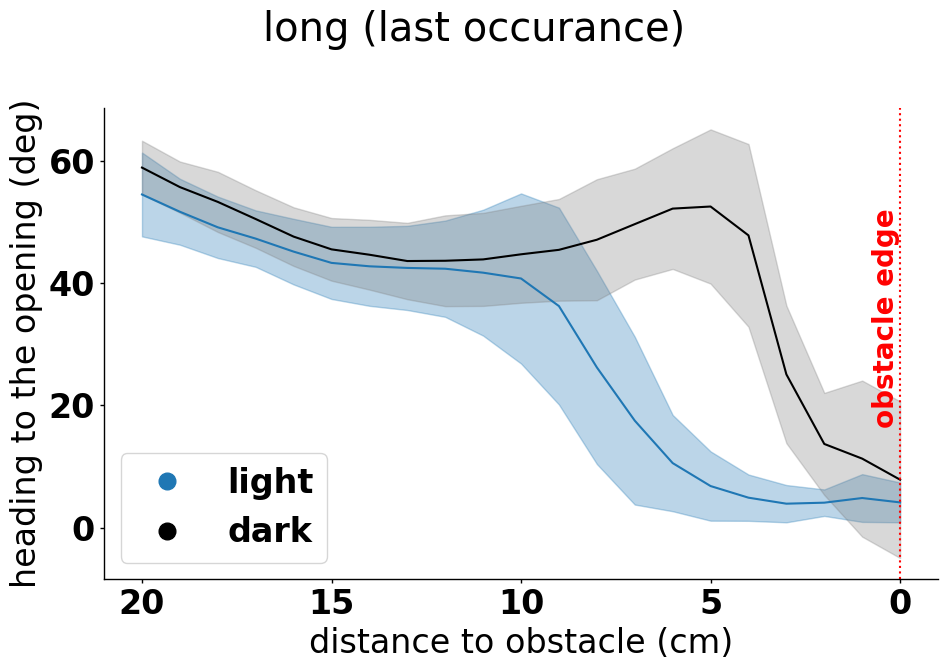

In [130]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[last_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[last_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[last_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[last_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

#for i in list(range(light_medians.shape[1])):
#    sd = np.nanstd(light_medians[:,i])/np.sqrt(len(light_medians))
#    light_sd.append(sd)
#light_sd = np.asarray(light_sd)
#
#for i in list(range(dark_medians.shape[1])):
#    sd = np.nanstd(dark_medians[:,i])/np.sqrt(len(dark_medians))
#    dark_sd.append(sd)
#dark_sd = np.asarray(dark_sd)
#
            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long (last occurance)')

In [55]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([long_nostart])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)



Text(0.5, 0.98, 'long')

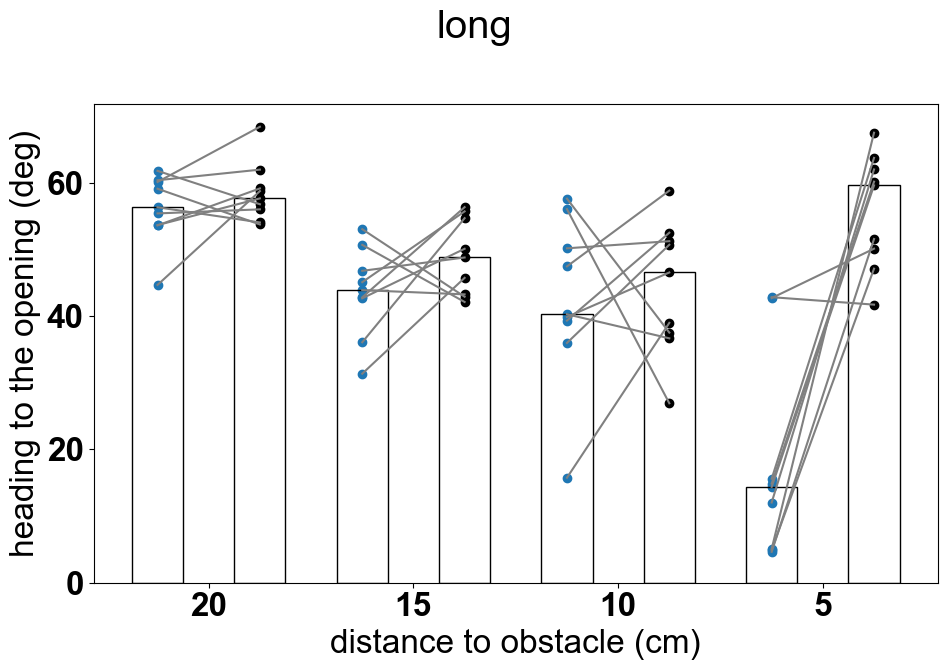

In [56]:
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('long')

Text(0.5, 0.98, 'long')

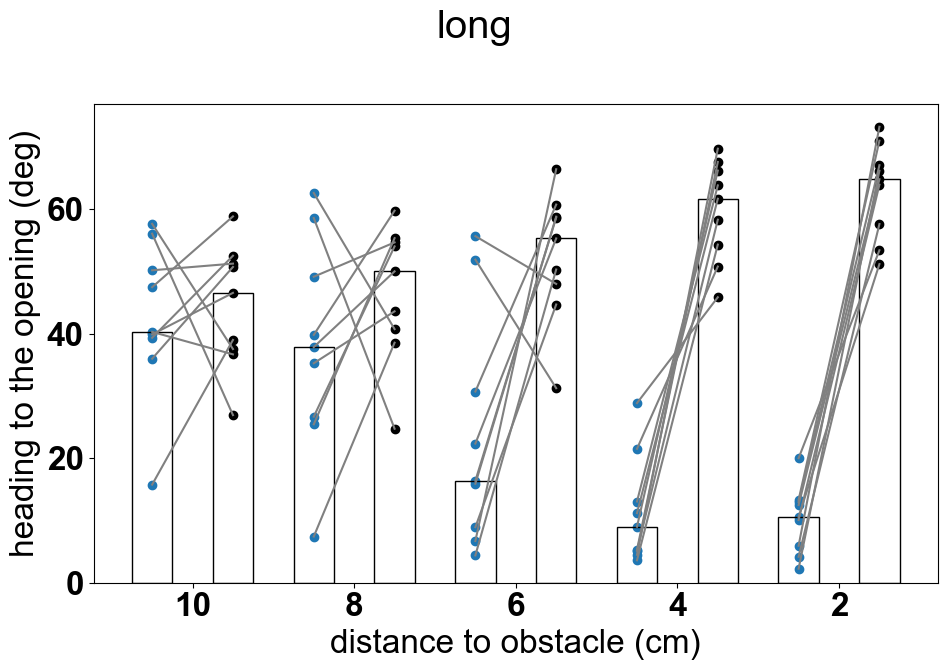

In [57]:
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,10],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,10],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,12],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,12],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,12]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,12],dark_medians[:,12]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,14],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,14],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,14]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,14],dark_medians[:,14]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,16],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,16],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,16]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,16],dark_medians[:,16]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,18],color = 'tab:blue')
ax.bar(8,np.nanmedian(light_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,18],color = 'black')
ax.bar(9,np.nanmedian(dark_medians[:,18]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],8),np.full(dark_medians.shape[0],9)),(light_medians[:,18],dark_medians[:,18]),color = 'grey')

ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
fig.suptitle('long')


In [58]:
dist_list = np.arange(0, 21, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat[0],stat[1],i)
    #print(stat[1])


1.072664326998051 0.31574510439066894 20
3.6190043473294495 0.07527977836615271 19
2.6792402643747075 0.12117911399135439 18
4.654745359248981 0.04651664697724945 17
3.574613318442483 0.0769200785592793 16
3.1981391740967813 0.09267244516714279 15
1.7794501137801757 0.2008948863312135 14
0.7719340127233513 0.39262299620481944 13
0.4289048033205375 0.521831503795422 12
0.25127770653633347 0.6230032265942581 11
0.12960003077774027 0.7235550277690759 10
0.5337304948739334 0.47560528858619555 9
1.6401530985913304 0.21855852356489638 8
7.5593496746109565 0.014250839876937692 7
16.18387056838499 0.0009834902823785358 6
44.43245325627963 5.42435930463749e-06 5
149.88065464815588 1.5387739619126669e-09 4
363.1702692072293 2.0122825202749988e-12 3
289.8865389120163 1.1269869743174318e-11 2
14.162939437407545 0.0016991320636004425 1
8.786506430061026 0.009136333711891794 0


short trials

Text(0.5, 0.98, 'short')

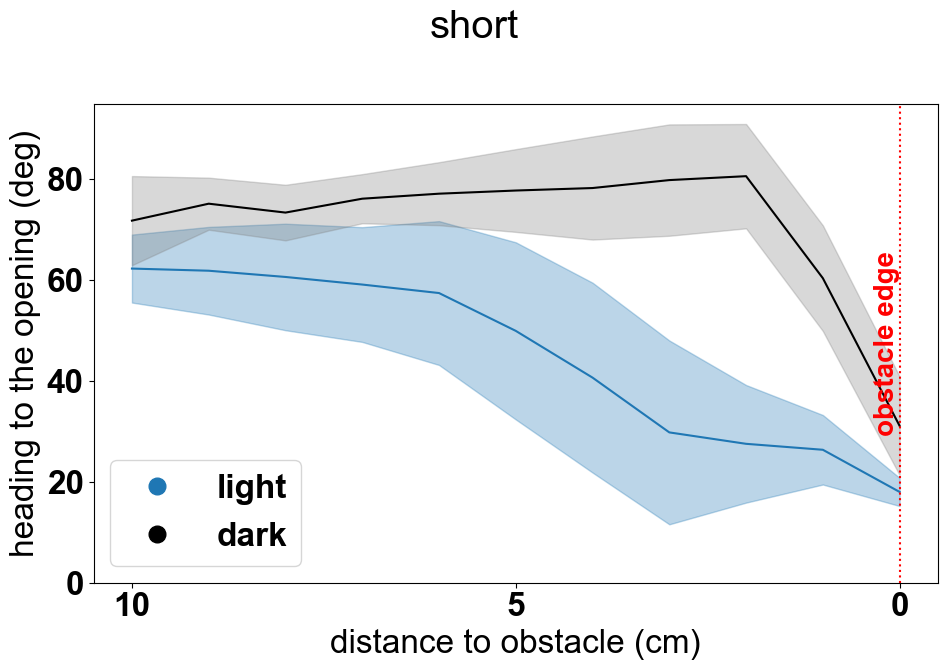

In [64]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew

    
    task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short')

Text(0.5, 0.98, 'long towards')

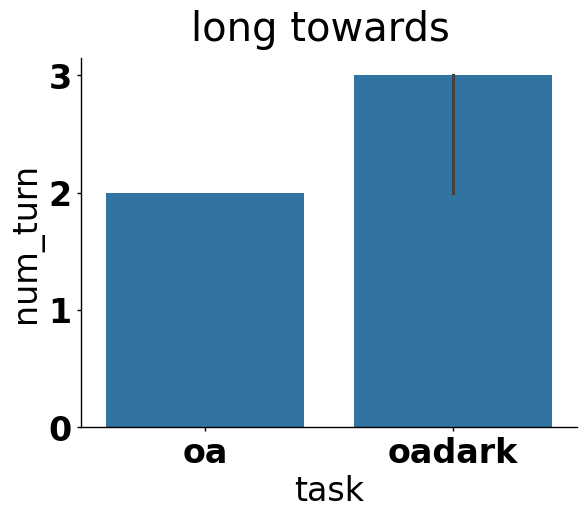

In [316]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data[data.distance_at_head_turn <=20], x = 'task', y = 'num_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

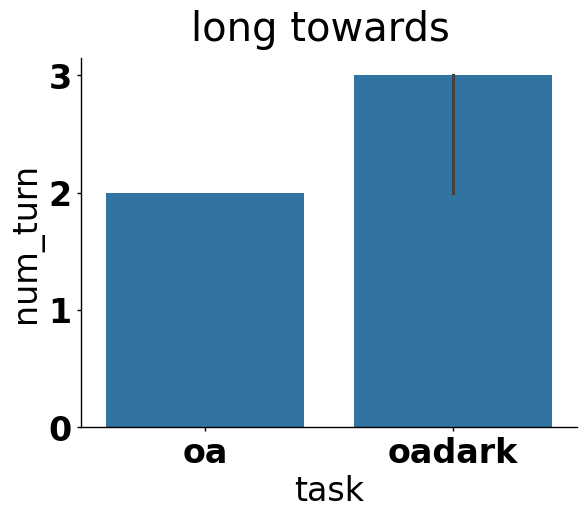

In [319]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data, x = 'task', y = 'num_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'long towards')

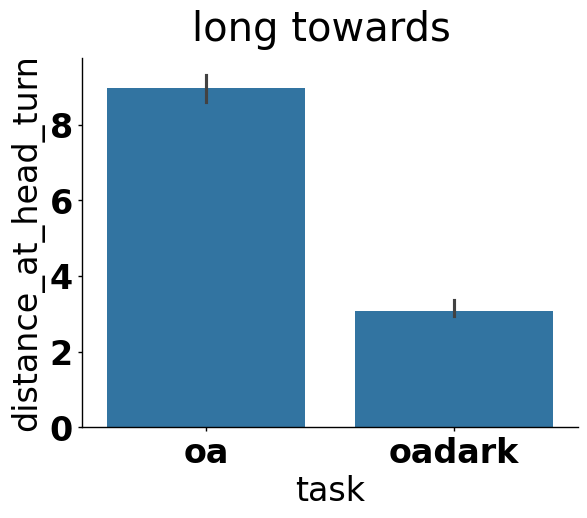

In [318]:
data = long_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data, x = 'task', y = 'distance_at_head_turn',estimator='median')
plt.suptitle('long towards')

Text(0.5, 0.98, 'short towards')

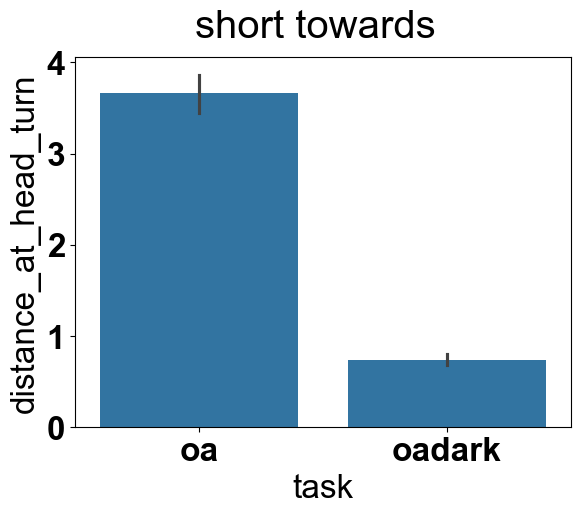

In [83]:
data = short_nostart
data = data[data.turn_to_obstacle == 'towards']
sns.barplot(data = data[data.distance_at_head_turn <=10], x = 'task', y = 'distance_at_head_turn',estimator='median')
plt.suptitle('short towards')

<AxesSubplot: xlabel='task', ylabel='distance_at_head_turn'>

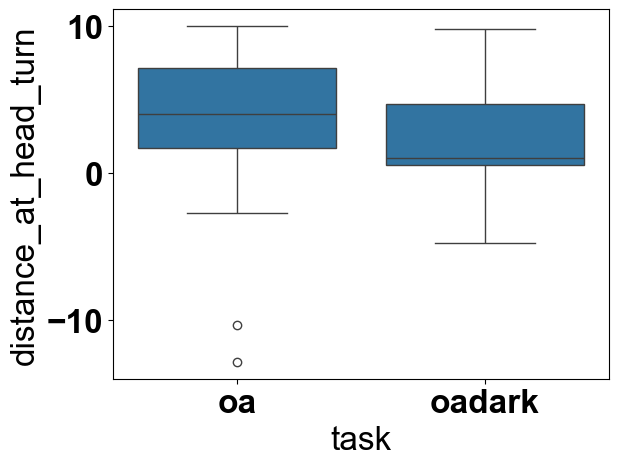

In [70]:
sns.boxplot(data = data[data.distance_at_head_turn <=10], x = 'task', y = 'distance_at_head_turn')

Text(0.5, 0.98, 'short first occurance towards')

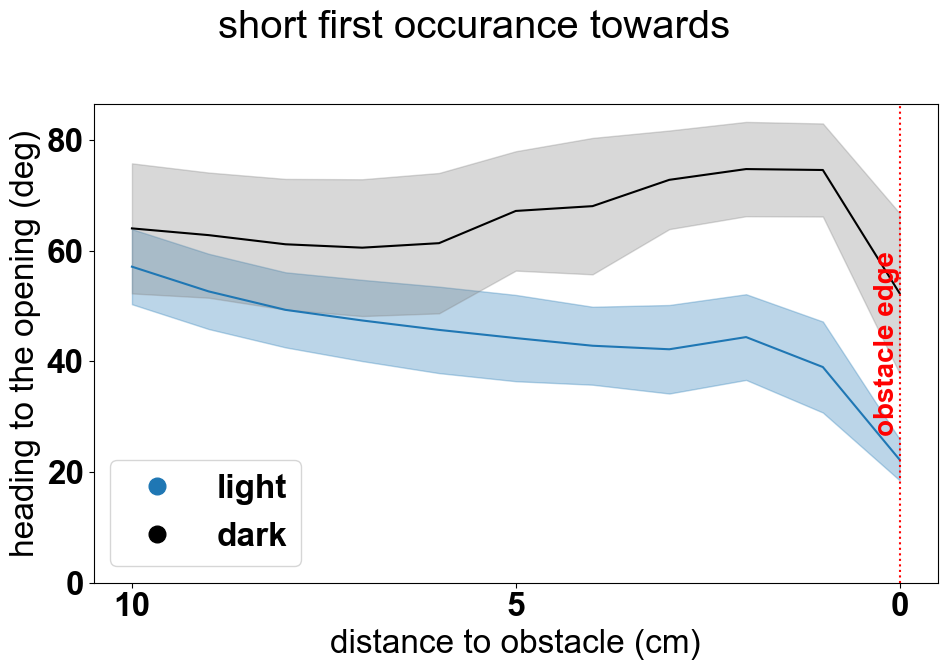

In [141]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#data = data[data.intial_distance > 10]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short first occurance towards')

Text(0.5, 0.98, 'short first occurance towards')

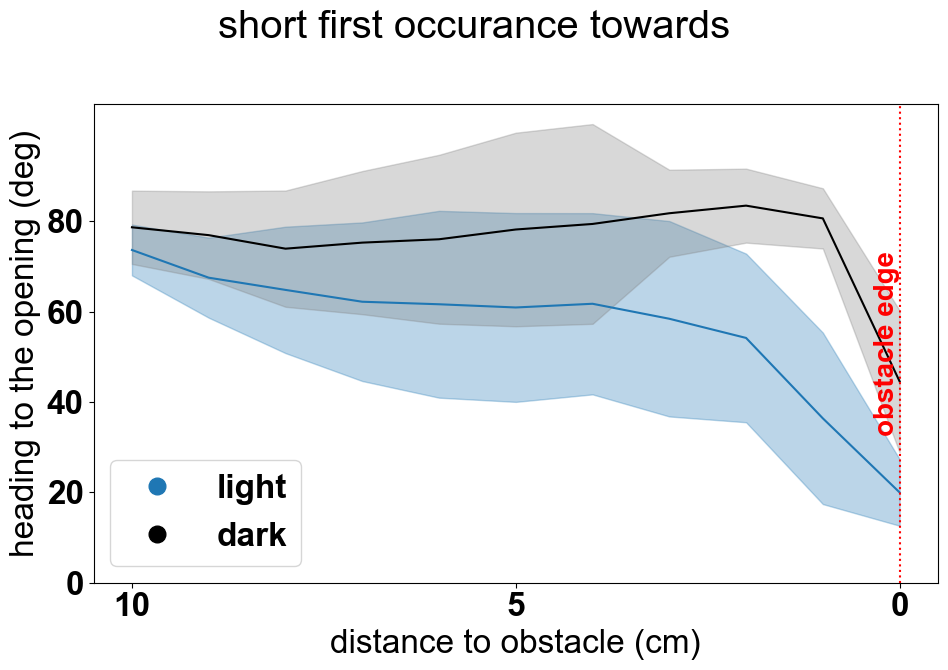

In [139]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
data = data[data.intial_distance == 10]
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short first occurance towards')

Text(0.5, 0.98, 'short')

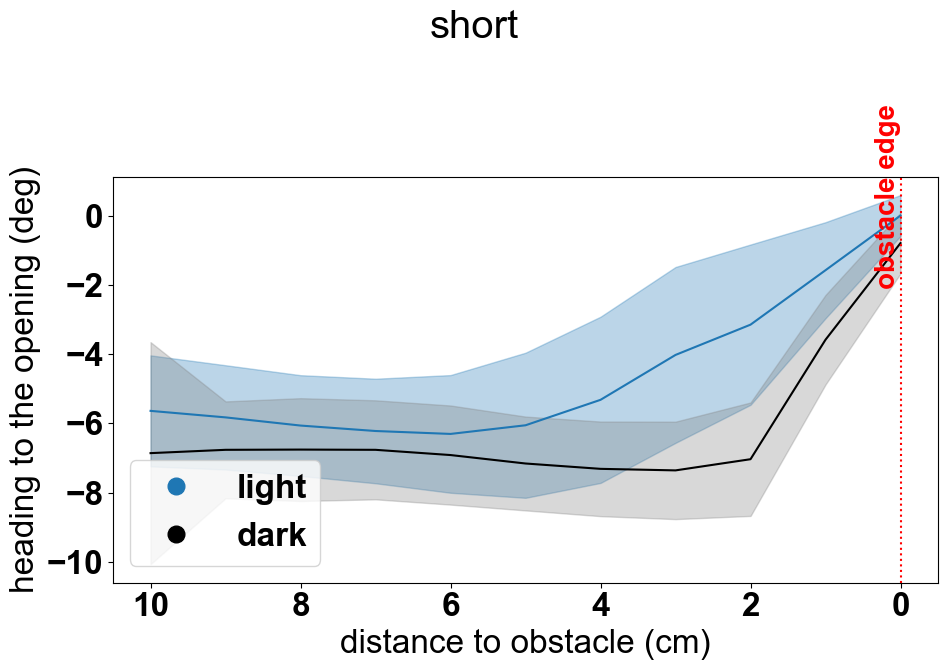

In [217]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
#ax.set_xticks([10,5,0])    
#ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short')

Text(0.5, 0.98, 'short')

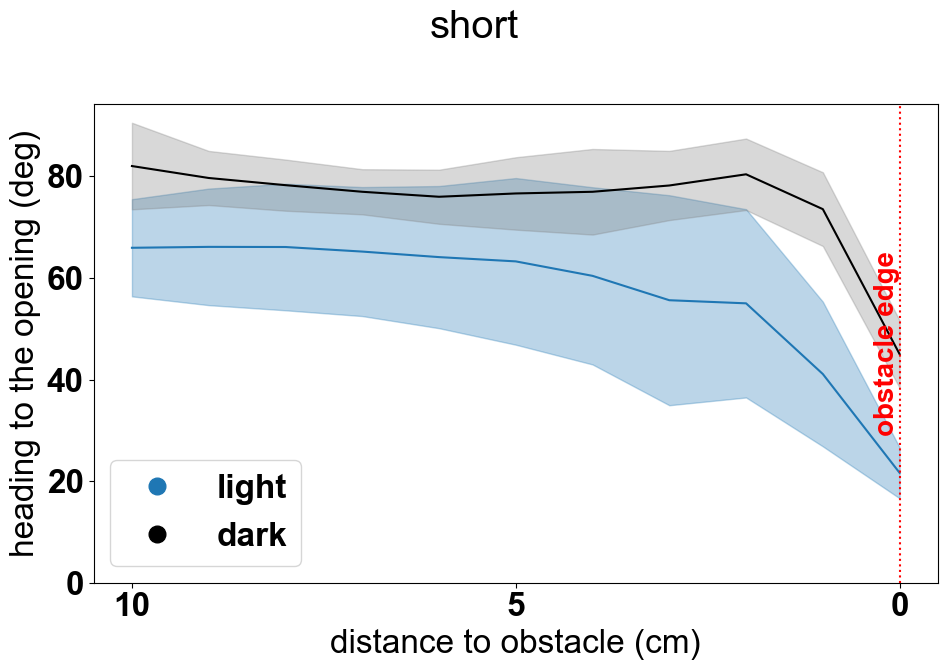

In [87]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
#data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('short')

In [85]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([short_nostart])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)



In [105]:
dark_medians[:,0]

array([86.72105703, 81.40806431, 60.13367837,         nan, 75.74459051,
       79.04748755, 80.43256672, 74.06748146, 63.06008183])

In [104]:
light_medians[:,0]

array([68.91220414, 66.45881216, 77.08208194, 66.3573819 , 56.66416528,
       62.8892944 , 65.700179  , 62.73198653, 50.29917828])

In [88]:
np.full(light_medians.shape[0],0)

array([0, 0, 0, 0, 0, 0, 0, 0, 0])

In [92]:
np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0]), array([1, 1, 1, 1, 1, 1, 1, 1, 1]))

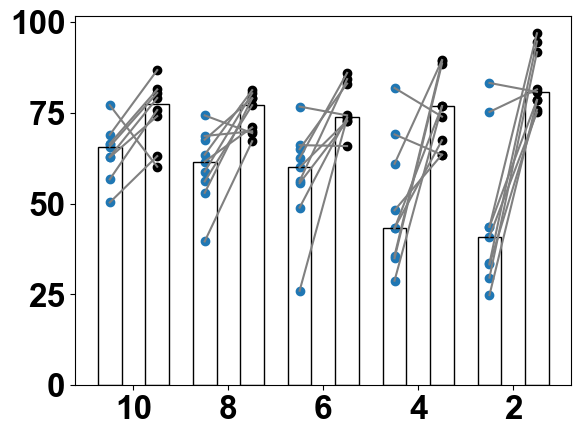

In [22]:
fig,ax = plt.subplots()
ax.set_xticks([.5,2.5,4.5,6.5,8.5],[10,8,6,4,2])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,2],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,2]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,2],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,2]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,2],dark_medians[:,2]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,4],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,4]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,4],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,4]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,4],dark_medians[:,4]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,6],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,6]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,6],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,6]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,6],dark_medians[:,6]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],8),light_medians[:,8],color = 'tab:blue')
ax.bar(8,np.nanmedian(light_medians[:,8]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],9),dark_medians[:,8],color = 'black')
ax.bar(9,np.nanmedian(dark_medians[:,8]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],8),np.full(dark_medians.shape[0],9)),(light_medians[:,8],dark_medians[:,8]),color = 'grey')

In [24]:
import numpy.ma as ma
f_oneway(dark_medians[:,0][~ma.masked_invalid(dark_medians[:,0]).mask],light_medians[:,0])

F_onewayResult(statistic=7.308192949781332, pvalue=0.0163480265944727)

In [23]:
import numpy.ma as ma
dist_list = np.arange(0, 11, 1)[::-1]
for ind,i in enumerate(dist_list):
    stat = f_oneway(dark_medians[:,ind],light_medians[:,ind])
    print(stat[0],stat[1],i)


nan nan 10
15.954115764605206 0.0010445545285888837 9
14.277507046399062 0.0016455211131190888 8
17.75617205469746 0.0006591903096963949 7
13.002150402516767 0.0023697467200423706 6
11.989237469102838 0.003207459166313174 5
15.591492232080276 0.0011498514646530122 4
19.04766470976888 0.00048161322088835056 3
27.41556927859326 8.157024863419057e-05 2
71.80958624271587 2.607153428456126e-07 1
149.36744798325975 1.5776253858279454e-09 0


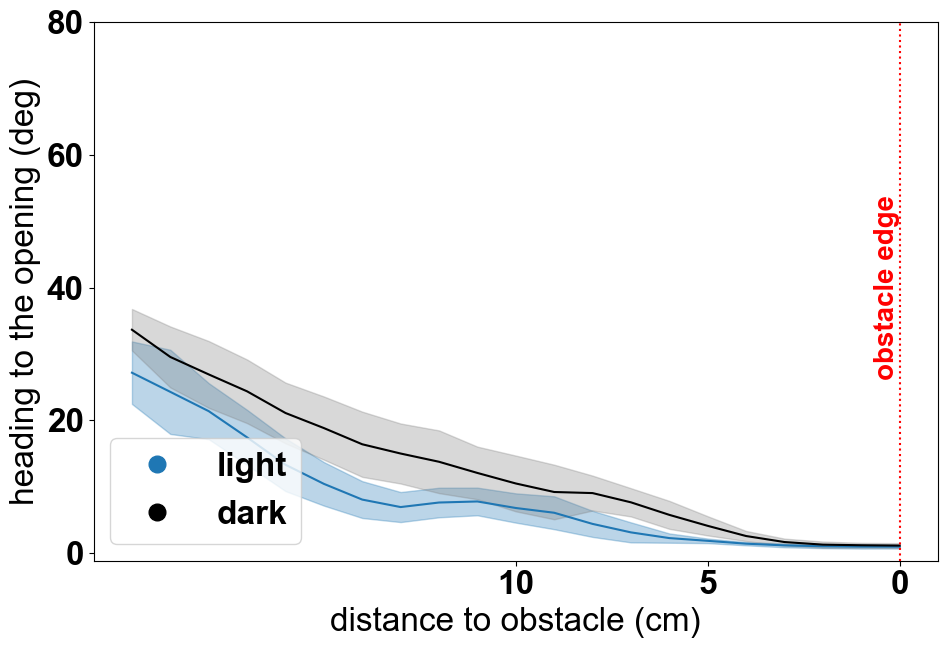

In [44]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([middle_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
#data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN','G8CKLT']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([0,20,40,60,80])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)

In [45]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([middle_nostart])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
#data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        print(animal,task)
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(light_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(dark_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

G8CK1LN oa
G8CK1LN oadark
G8CK1LT oa
G8CK1LT oadark
G8CK1RT oa
G8CK1RT oadark
G8CK1TT oa
G8CK1TT oadark
G8CKLN oa
G8CKLN oadark
G8CKLT oa
G8CKLT oadark
G8CKRN oa
G8CKRN oadark
G8CKRT oa
G8CKRT oadark
G8CKTT oa
G8CKTT oadark


In [43]:
data

,level_0,first_poke,second_poke,trial_timestamps,trial_vidframes,nose_x,nose_y,leftear_x,leftear_y,rightear_x,...,distance_at_head_turn_2_index,distance_at_head_turn_2_indexs,angle_at_head_turn_2,num_turn,towards_num_turn,away_num_turn,right_num_turn,right_turns_distances,left_num_turn,left_turns_distances
2725,2725,50372.705280,50376.822080,"[50372.717043, 50372.735552, 50372.75054, 5037...","[3462, 3463, 3464, 3465, 3466, 3467, 3468, 346...","[117.01360321044922, 116.47345733642578, 115.7...","[274.8700866699219, 273.04595947265625, 272.20...","[124.90813446044922, 123.60502624511719, 122.4...","[274.9167785644531, 274.6429443359375, 274.652...","[124.64678192138672, 123.75786590576172, 123.5...",...,50.0,"[2, 28, 43, 50]",122.048796,4.0,2.0,2.0,2.0,"[9.181359965756421, 1.491899425085947]",2.0,"[0.7586340860166665, 1.373382913282633]"
2726,2726,50376.822080,50379.337318,"[50376.835302, 50376.85198, 50376.868544, 5037...","[[3709, 3710, 3711, 3712, 3713, 3714, 3715, 37...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[689.8196411132812, 690.0974731445312, 690.154...","[260.5218200683594, 260.9630432128906, 261.623...","[681.4044189453125, 681.662841796875, 682.2274...",...,45.0,"[33, 45]",11.453429,2.0,3.0,2.0,1.0,[3.8642608717014326],1.0,[2.7055099955799076]
2727,2727,50379.337318,50381.815667,"[50379.353676, 50379.369472, 50379.386163, 503...","[3860, 3861, 3862, 3863, 3864, 3865, 3866, 386...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[123.86229705810547, 123.18112182617188, 122.9...","[277.52691650390625, 277.44525146484375, 277.5...","[128.97134399414062, 128.38442993164062, 128.3...",...,2.0,[2],13.616186,1.0,0.0,NaN,0.0,[],1.0,[8.974062457433714]
2736,2736,50419.178355,50421.722150,"[50419.183091, 50419.199846, 50419.216614, 504...","[[6249, 6250, 6251, 6252, 6253, 6254, 6255, 62...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[688.37744140625, 688.2561645507812, 688.29699...","[260.0295715332031, 259.51763916015625, 259.84...","[680.450927734375, 680.7147216796875, 680.7387...",...,2.0,"[2, 15]",36.117510,2.0,0.0,NaN,0.0,[],2.0,"[18.784905099176257, 11.408403947068479]"
2737,2737,50421.722150,50424.208614,"[50421.734131, 50421.750835, 50421.768294, 504...","[6402, 6403, 6404, 6405, 6406, 6407, 6408, 640...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[126.54217529296875, 125.79476928710938, 125.6...","[279.0948486328125, 279.1933898925781, 278.219...","[132.26815795898438, 131.5294647216797, 130.71...",...,2.0,[2],27.672843,1.0,0.0,NaN,0.0,[],1.0,[9.521666517390445]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14536,14536,55907.699212,55910.243033,"[55907.699276, 55907.71575, 55907.733376, 5590...","[13713, 13714, 13715, 13716, 13717, 13718, 137...","[90.92820739746094, 90.42640686035156, 89.9016...","[262.5146484375, 262.6229553222656, 261.961486...","[95.67121124267578, 95.19441986083984, 94.7905...","[261.8681335449219, 262.1152648925781, 261.792...","[98.95252227783203, 97.65525817871094, 97.1992...",...,13.0,"[2, 13]",4.918050,2.0,0.0,NaN,0.0,[],2.0,"[17.042384319912472, 9.939674629126293]"
14537,14537,55910.243033,55912.491942,"[55910.249779, 55910.267865, 55910.28334, 5591...","[[13866, 13867, 13868, 13869, 13870, 13871, 13...","[670.7637939453125, 673.1174926757812, 673.373...","[265.2012939453125, 265.2127685546875, 265.635...","[658.1209106445312, 664.5240478515625, 665.381...","[262.3766784667969, 257.009765625, 257.6093444...","[665.65283203125, 666.5121459960938, 666.28002...",...,NaN,NaN,NaN,0.0,0.0,NaN,0.0,[],0.0,[]
14542,14542,55959.485260,55961.705395,"[55959.500416, 55959.517196, 55959.53454, 5595...","[[16820, 16821, 16822, 16823, 16824, 16825, 16...","[674.292724609375, 674.9031982421875, 675.8319...","[262.27545166

In [39]:
animal

'G8CKTT'

In [40]:
dark_array.shape

(6, 21)

In [34]:
light_medians[:,0]

array([51.38429092, 24.88953155, 41.24533467, 28.62193945, 29.14859371,
       39.90924497,         nan, 12.15323294])

In [35]:
dark_medians[:,0]

array([32.90673655, 40.87962659, 44.13525584, 32.31649345, 45.00927875,
               nan, 63.38880761, 46.65386781])

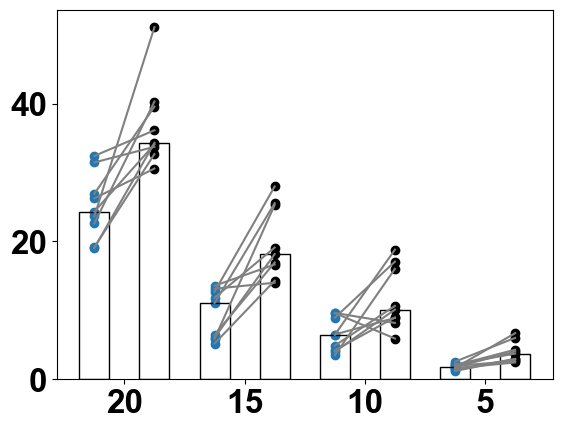

In [46]:
fig,ax = plt.subplots()
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')

In [ ]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['ts_zero_out_angle_to_corner'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)

            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([0,20,40,60])  
ax.set_ylabel('heading to the opening (deg)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, ax.get_ylim()[1]/2,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=24)
fig.suptitle('long')

Text(0.5, 0.98, 'away')

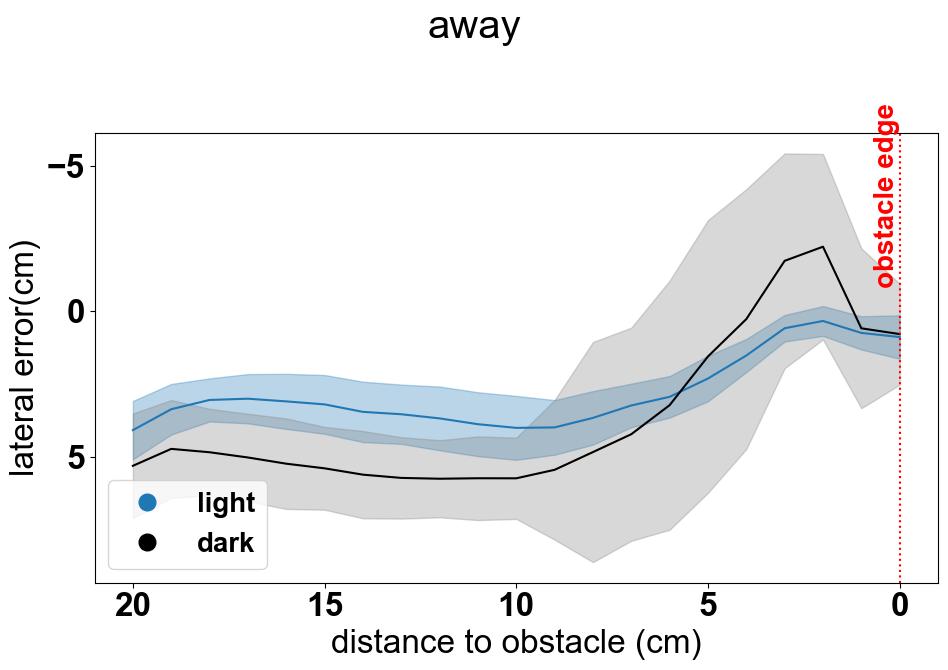

In [59]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'away']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
#ax.set_yticks([-8,-4,0,4]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
fig.suptitle('away')

Text(0.5, 0.98, 'towards')

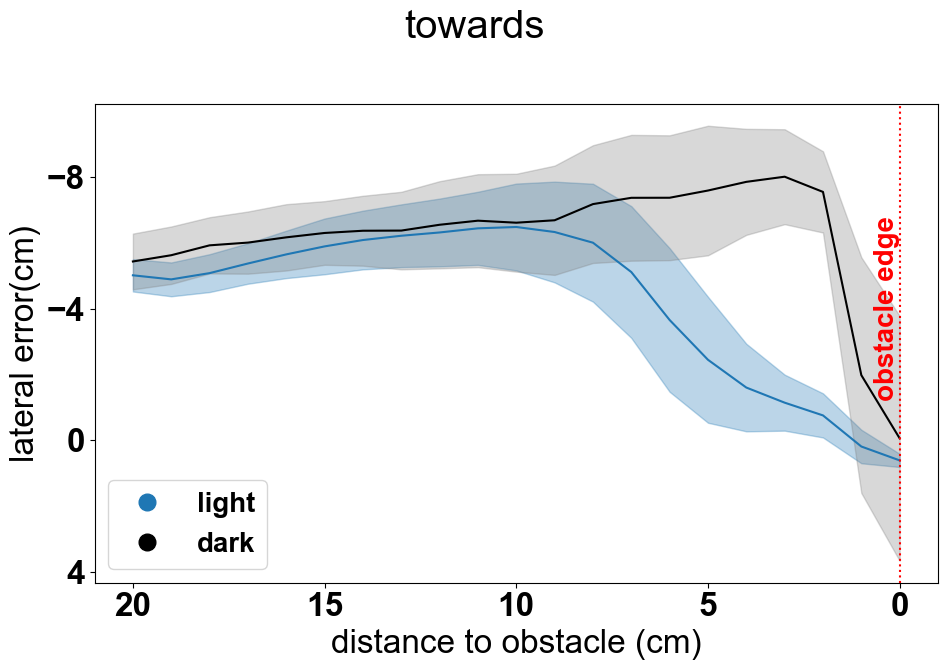

In [57]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([long_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([20,15,10,5,0])    
ax.set_yticks([-8,-4,0,4]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
fig.suptitle('towards')

In [18]:
xnew =  np.arange(0, 21, 1)
xnew= np.flip(xnew)


ax.invert_xaxis()
data = pd.concat([joint])
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
data = drop_nans_in_columns(data,'obstacle_ind')
data = drop_nans_in_columns(data,'lateral_error')
data = data[data.turn_to_obstacle == 'towards']
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []

for animal,animal_df in  data.groupby(['animal']):
    for task,task_df in  animal_df.groupby(['task']):
        rows = task_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(task_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew


        task_angle_median= np.nanmedian(angle_array,axis = 0)

    
        if task == 'oa':
            light_array = angle_array
            light_angle_median= np.nanmedian(angle_array,axis = 0)
            light_medians.append(light_angle_median)
            #ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        else:
            dark_array = angle_array
            dark_angle_median= np.nanmedian(angle_array,axis = 0)
            dark_medians.append(dark_angle_median)
            #ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

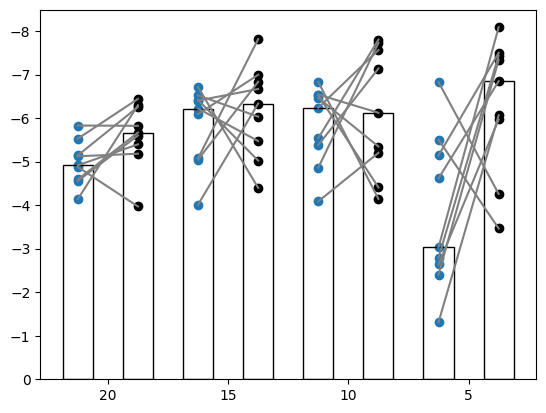

In [21]:
fig,ax = plt.subplots()
ax.set_xticks([.5,2.5,4.5,6.5],[20,15,10,5])

ax.scatter(np.full(light_medians.shape[0],0),light_medians[:,0],color = 'tab:blue')
ax.bar(0,np.nanmedian(light_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],1),dark_medians[:,0],color = 'black')
ax.bar(1,np.nanmedian(dark_medians[:,0]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],0),np.full(dark_medians.shape[0],1)),(light_medians[:,0],dark_medians[:,0]),color = 'grey')


ax.scatter(np.full(light_medians.shape[0],2),light_medians[:,5],color = 'tab:blue')
ax.bar(2,np.nanmedian(light_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],3),dark_medians[:,5],color = 'black')
ax.bar(3,np.nanmedian(dark_medians[:,5]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],2),np.full(dark_medians.shape[0],3)),(light_medians[:,5],dark_medians[:,5]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],4),light_medians[:,10],color = 'tab:blue')
ax.bar(4,np.nanmedian(light_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],5),dark_medians[:,10],color = 'black')
ax.bar(5,np.nanmedian(dark_medians[:,10]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],4),np.full(dark_medians.shape[0],5)),(light_medians[:,10],dark_medians[:,10]),color = 'grey')

ax.scatter(np.full(light_medians.shape[0],6),light_medians[:,15],color = 'tab:blue')
ax.bar(6,np.nanmedian(light_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.scatter(np.full(dark_medians.shape[0],7),dark_medians[:,15],color = 'black')
ax.bar(7,np.nanmedian(dark_medians[:,15]),fill = False,color = 'tab:blue',width=.5)
ax.plot((np.full(light_medians.shape[0],6),np.full(dark_medians.shape[0],7)),(light_medians[:,15],dark_medians[:,15]),color = 'grey')
ax.invert_yaxis()

Text(0.5, 0.98, 'short')

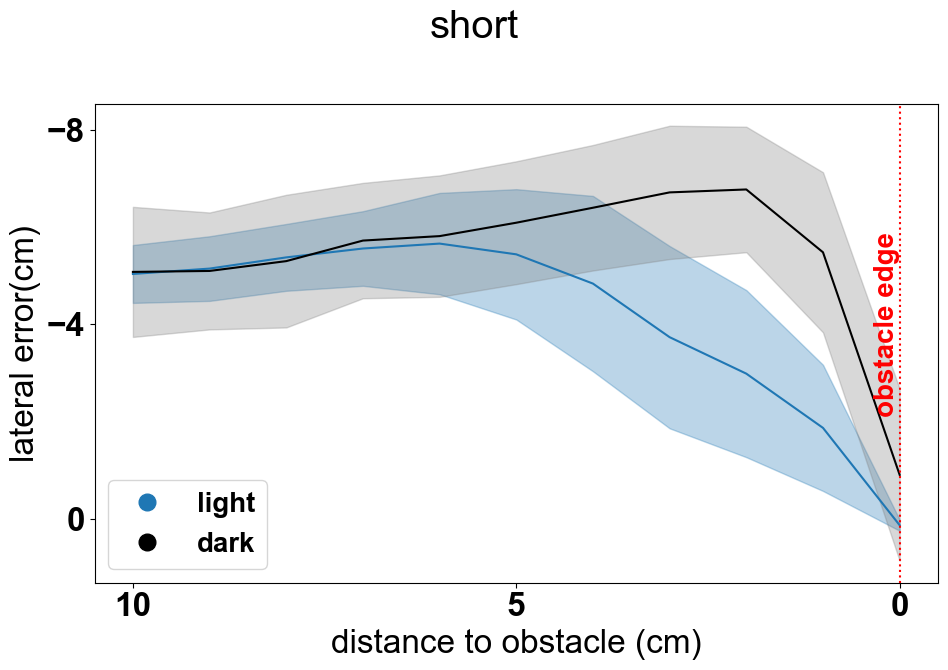

In [94]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        #x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        #y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x,y,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            #x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
           # y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x,y,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
fig.suptitle('short')

Text(0.5, 0.98, 'short towards fisrt occurance')

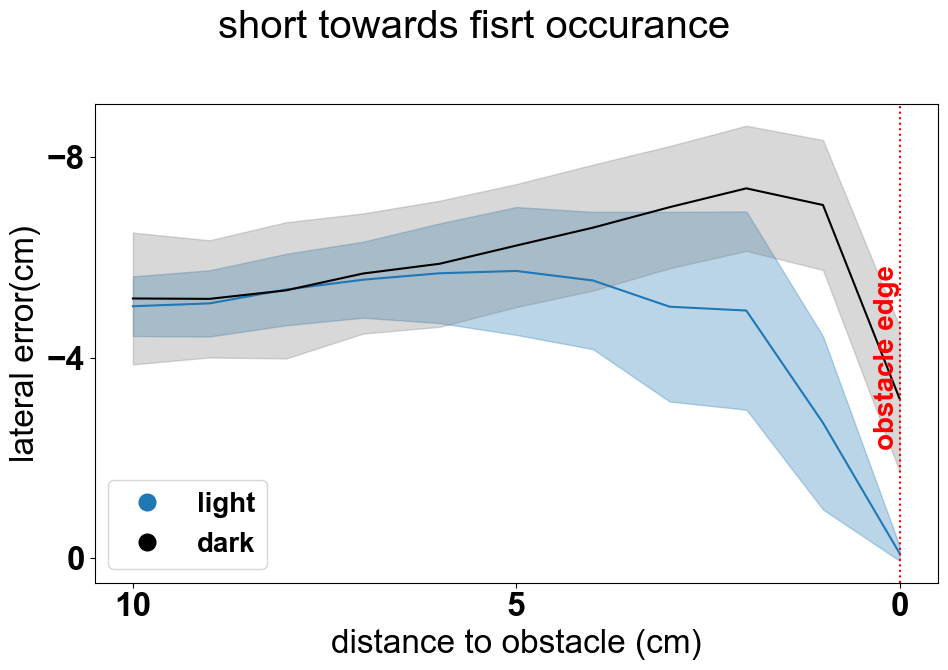

In [91]:
xnew =  np.arange(0, 11, 1)
xnew= np.flip(xnew)
fig,ax = plt.subplots(layout = 'tight',figsize = (10,7) )

ax.invert_xaxis()
data = pd.concat([short_nostart])
data = drop_nans_in_columns(data,'obstacle_ind')
data = data[data.turn_to_obstacle == 'towards']
animals_to_drop = [ 'J704RT', 'J704NN', 'J704LT', 'J704LN','J701LT', 'J701RT', 'J701NN', 'J701RN']
data = data[~data.animal.isin(animals_to_drop)]
#zero_out_angle(data)
#ts_angle_to_open_corner(data)
#zero_out_angle(data)
light_medians = []
dark_medians = []
light_sd = []
dark_sd = []
for task,task_df in  data.groupby(['task']):
  
    rows = task_df.shape[0]
    angle_array = np.empty([rows,len(xnew)])
    angle_array[:] =np.nan 
    for i,row in enumerate(task_df.iterrows()):
        x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
        x1 = x[first_occurrence_indices(np.round(x))]
        y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
        y1 = y[first_occurrence_indices(np.round(x))]
        if sum(y) == 0:
            continue
        else:
            interpolater = interp1d(x1,y1,bounds_error=False)
            ynew = interpolater(xnew)
            angle_array[i] = ynew
            #ax.plot(x1,y1,c = 'tab:blue',alpha = .1)

    
    #task_angle_median= np.nanmedian(angle_array,axis = 0)

 
    if task == 'oa':
        light_array = angle_array
        light_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,light_angle_median,c = 'tab:blue',alpha = 1)
        
    else:
        dark_array = angle_array
        dark_angle_median= np.nanmedian(angle_array,axis = 0)
        ax.plot(xnew,dark_angle_median,c = 'black',alpha = 1)
        

    for animal,animal_df in task_df.groupby(['animal']):
        rows = animal_df.shape[0]
        angle_array = np.empty([rows,len(xnew)])
        angle_array[:] =np.nan 
        for i,row in enumerate(animal_df.iterrows()):
            x = row[1]['ts_distance_from_edge'][:int(row[1]['obstacle_ind'])].astype(float)
            x1 = x[first_occurrence_indices(np.round(x))]
            y = row[1]['lateral_error'][:int(row[1]['obstacle_ind'])].astype(float)
            y1 = y[first_occurrence_indices(np.round(x))]
            if sum(y) == 0:
                continue
            else:
                interpolater = interp1d(x1,y1,bounds_error=False)
                ynew = interpolater(xnew)
                angle_array[i] = ynew
        animal_angle_median= np.nanmedian(angle_array,axis = 0)
        if animal_df.task.unique() == 'oa':
            light_medians.append(animal_angle_median)
            
        else:
            dark_medians.append(animal_angle_median)

light_medians = np.asarray(light_medians)
dark_medians = np.asarray(dark_medians)

for i in list(range(light_medians.shape[1])):
    sd = np.nanstd(light_medians[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)

for i in list(range(dark_medians.shape[1])):
    sd = np.nanstd(dark_medians[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


            






ax.fill_between(xnew, light_angle_median-light_sd, light_angle_median+light_sd, color='tab:blue', alpha=0.3, label='IQR')   
ax.fill_between(xnew, dark_angle_median-dark_sd, dark_angle_median+dark_sd, color='tab:grey', alpha=0.3, label='IQR')  
ax.set_xticks([10,5,0])    
ax.set_yticks([-8,-4,0]) 
ax.set_ylabel('lateral error(cm)')
ax.set_xlabel('distance to obstacle (cm)')
ax.axvline(0, color='r', ls=':')
ax.text(0, -4,'obstacle edge', color='r', ha='right', va='center', rotation=90,fontsize=20)
   
markers = [plt.Line2D([0,0],[0,0],color=color, marker='o', linestyle='',markersize=12) for color in ['tab:blue','black']]
ax.legend(markers, ['light','dark'], numpoints=1,loc = 'lower left',fontsize=20)
ax.invert_yaxis()
fig.suptitle('short towards fisrt occurance')

Text(0.5, 0.03, 'distance to obstacle (cm)')

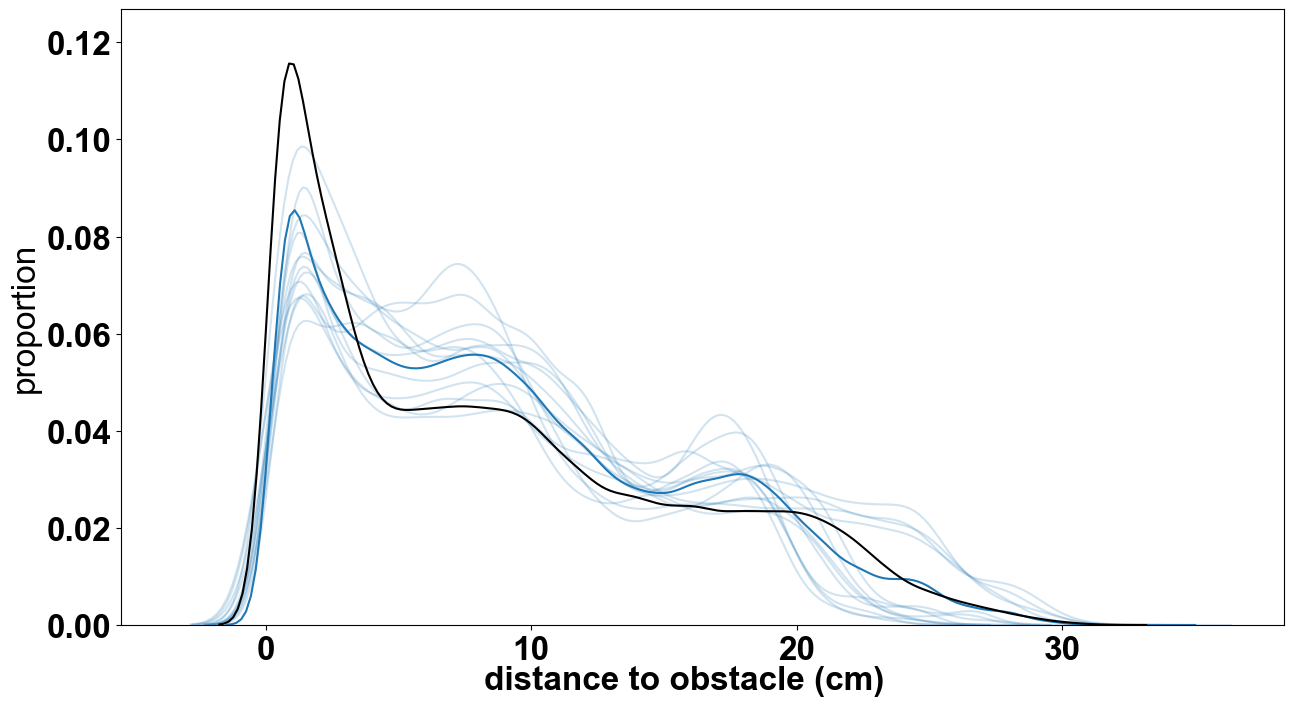

In [33]:
data = joint
fig,ax = plt.subplots(1,1,figsize=(15,8),sharey =True)
light = data[data.task =='oa']
light_dist = flatten_list_of_arrays(light.ts_distance_from_edge.to_list())
light_dist = light_dist[np.where((light_dist>=0))]
 
sns.kdeplot(ax = ax,data = light_dist,color = 'tab:blue')

for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_list())
    ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    sns.kdeplot(ax = ax,data = ani_light_dists,color = 'tab:blue', alpha = .2 )

dark = data[data.task =='oadark']
dark_dist = flatten_list_of_arrays(dark.ts_distance_from_edge.to_list())
dark_dist = dark_dist[np.where((dark_dist>=0))]

sns.kdeplot(ax = ax,data = dark_dist,color = 'black')

for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = flatten_list_of_arrays(ani_df.ts_distance_from_edge.to_list())
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    sns.kdeplot(ax = ax,data = ani_dark_dists,color = 'black', alpha = .2,linestyle ='none' )

ax.set_xticks([0,10,20,30])

ax.set_ylabel('proportion')
fig.text(0.5, 0.03, 'distance to obstacle (cm)', ha='center')


In [22]:
f_oneway(dark_medians[:,0],light_medians[:,0])

F_onewayResult(statistic=4.692024419758573, pvalue=0.04574962649947531)

In [23]:
f_oneway(dark_medians[:,5],light_medians[:,5])

F_onewayResult(statistic=0.5360668096445641, pvalue=0.4746565831631724)

In [24]:
f_oneway(dark_medians[:,10],light_medians[:,10])

F_onewayResult(statistic=0.3356692264706663, pvalue=0.5704078998589119)

In [25]:
f_oneway(dark_medians[:,15],light_medians[:,15])

F_onewayResult(statistic=10.107399974528644, pvalue=0.005826677470858147)

In [26]:
f_oneway(dark_medians[:,20],light_medians[:,20])

F_onewayResult(statistic=5.610307320560603, pvalue=0.03078010616718436)

In [7]:
long_nostart.intial_lateral_error.group


8       -2.209042
12       4.971173
17      -6.185573
22       6.595616
24      -6.523490
           ...   
14500    8.429366
14515    8.808606
14523   -7.732743
14535    5.552014
14547    9.117446
Name: intial_lateral_error, Length: 5295, dtype: float64

In [8]:
data = long_nostart[(long_nostart.obstacle_cluster == 1 ) & (long_nostart.turn_to_obstacle == 'towards' )
                    & (long_nostart.odd=='left')]

In [12]:
split_range_into_parts(data.intial_lateral_error.to_numpy().min(),data.intial_lateral_error.to_numpy().max(),4)

[(-17.1751700988669, -8.313858647986105),
 (-8.313858647986105, 0.5474528028946892),
 (0.5474528028946892, 9.408764253775484),
 (9.408764253775484, 18.27007570465628)]

In [28]:
split_range_into_parts(-20,5,4)

[(-20, -13.75), (-13.75, -7.5), (-7.5, -1.25), (-1.25, 5.0)]

<AxesSubplot: >

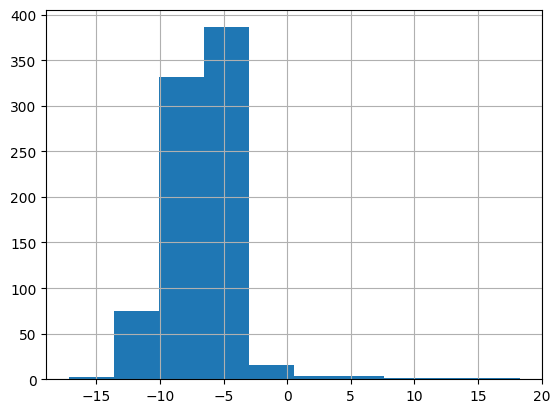

In [17]:
data.intial_lateral_error.hist()

Text(0.5, 1.0, 'towards')

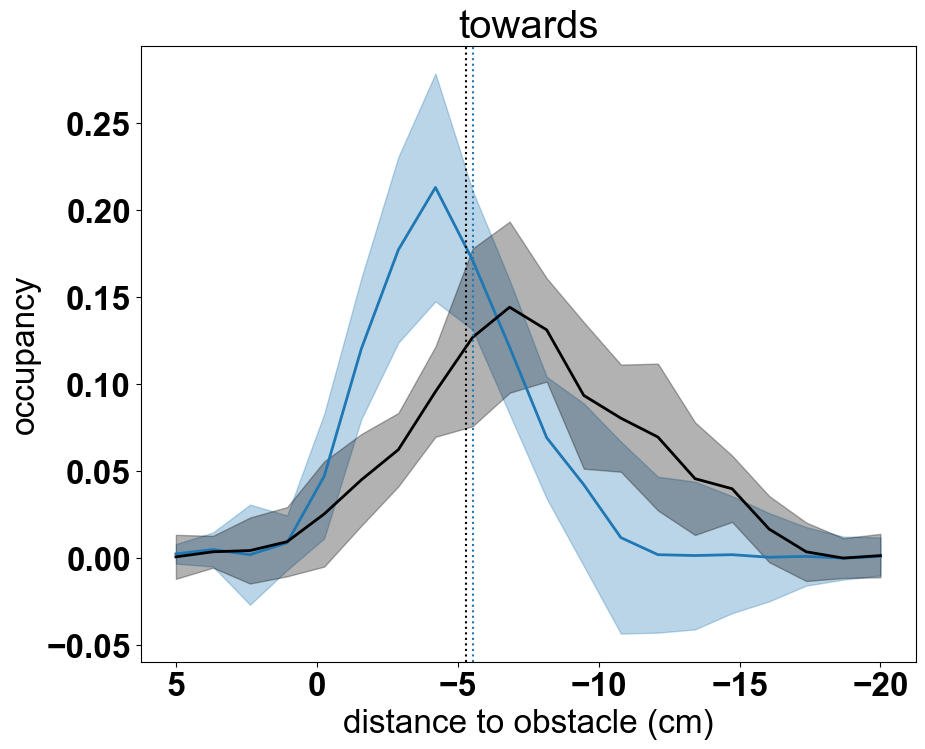

In [106]:
xnew =  np.linspace(-20, 5, 20)
data = pd.concat([short_nostart])
data = data[data.turn_to_obstacle == 'towards']
fig,ax = plt.subplots(1,1,figsize=(10,8),sharey =True)
light = data[data.task =='oa']
light_dist = (light.intial_lateral_error.to_numpy())
#light_dist = light_dist[np.where((light_dist>=0))]
light_dist = light_dist[np.where((light_dist<=5))]
light_counts, light_bins = np.histogram(light_dist, bins=20)
light_hist = (light_counts/sum(light_counts))
ax.plot(xnew, light_hist, 'b-', linewidth=2, label='Line',color='tab:blue')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
light_prob = []
for ani,ani_df in light.groupby(['animal']):
    ani_light_dists = (ani_df.intial_lateral_error.to_numpy())
    #ani_light_dists = ani_light_dists[np.where((ani_light_dists>=0))]
    ani_light_dists = ani_light_dists[np.where((ani_light_dists<=5))]
    counts, bins = np.histogram(ani_light_dists, bins=20)
    light_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
light_prob = np.asarray(light_prob)
light_sd = []
for i in list(range(light_prob.shape[1])):
    sd = np.nanstd(light_prob[:,i])
    light_sd.append(sd)
light_sd = np.asarray(light_sd)


ax.fill_between(xnew, (light_counts/sum(light_counts))-light_sd, (light_counts/sum(light_counts))+light_sd, color='tab:blue', alpha=0.3, label='IQR')   


dark = data[data.task =='oadark']
dark_dist = (dark.intial_lateral_error.to_numpy())
#dark_dist = dark_dist[np.where((dark_dist>=0))]
dark_dist = dark_dist[np.where((dark_dist<=5))]
dark_counts, dark_bins = np.histogram(dark_dist, bins=20)
dark_hist = (dark_counts/sum(dark_counts))
ax.plot(xnew, dark_hist, 'b-', linewidth=2, label='Line',color='black')
#ax[0].fill_between(bins[:-1], counts, alpha=0.5, label='Fill')
dark_prob = []
for ani,ani_df in dark.groupby(['animal']):
    ani_dark_dists = (ani_df.intial_lateral_error.to_numpy())
    #ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists>=0))]
    ani_dark_dists = ani_dark_dists[np.where((ani_dark_dists<=5))]
    counts, bins = np.histogram(ani_dark_dists, bins=20)
    dark_prob.append(counts/sum(counts))
    #ax.plot(bins[:-1], (counts/sum(counts)), 'b-', linewidth=2, label='Line', alpha=0.2,color = 'tab:blue')
    #ax[0].fill_between(bins[:-1], counts, alpha=0.2, label='Fill')
dark_prob = np.asarray(dark_prob)
dark_sd = []
for i in list(range(dark_prob.shape[1])):
    sd = np.nanstd(dark_prob[:,i])
    dark_sd.append(sd)
dark_sd = np.asarray(dark_sd)


ax.axvline(np.nanmedian(light_dist), color='tab:blue', ls=':')
ax.axvline(np.nanmedian(dark_dist), color='black', ls=':')


ax.fill_between(xnew, (dark_counts/sum(dark_counts))-dark_sd, (dark_counts/sum(dark_counts))+dark_sd, color='black', alpha=0.3, label='IQR')   

ax.set_ylabel('occupancy')  
ax.set_xlabel('distance to obstacle (cm)')
ax.invert_xaxis()
ax.set_title('towards')

In [46]:
np.nanmean(dark_dist)/np.sqrt(len(dark_dist))

-0.14686824992531913

In [45]:
np.nanmean(light_dist)/np.sqrt(len(light_dist))

-0.12620575754258073

(array([  2.,  28., 118., 207., 310., 374., 218.,  97.,  19.,   6.]),
 array([-15.81887167, -13.73958355, -11.66029544,  -9.58100732,
         -7.50171921,  -5.42243109,  -3.34314298,  -1.26385486,
          0.81543325,   2.89472136,   4.97400948]),
 <BarContainer object of 10 artists>)

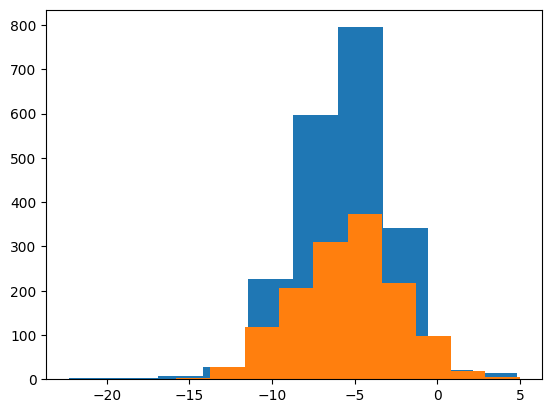

In [39]:
plt.hist(light_dist)
plt.hist(dark_dist)

(array([  6.,  19.,  97., 218., 374., 310., 207., 118.,  28.,   2.]),
 array([-0.00066135, -0.00038489, -0.00010842,  0.00016804,  0.00044451,
         0.00072097,  0.00099744,  0.0012739 ,  0.00155037,  0.00182683,
         0.0021033 ]),
 <BarContainer object of 10 artists>)

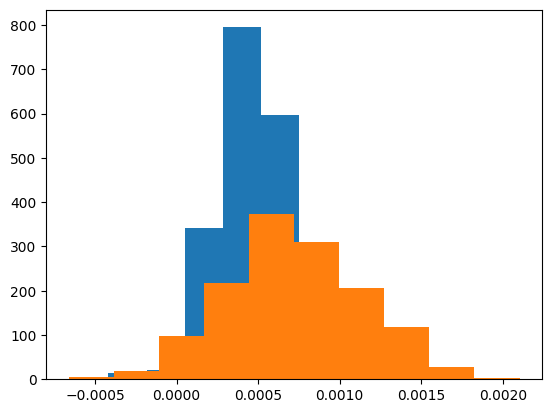

In [38]:
plt.hist(light_dist/sum(light_dist))
plt.hist(dark_dist/sum(dark_dist))

In [37]:
dark_prob

array([[0.01492537, 0.        , 0.        , 0.04477612, 0.02985075,
        0.01492537, 0.13432836, 0.07462687, 0.11940299, 0.13432836,
        0.05970149, 0.05970149, 0.08955224, 0.02985075, 0.08955224,
        0.01492537, 0.02985075, 0.04477612, 0.        , 0.01492537],
       [0.01515152, 0.        , 0.01515152, 0.03030303, 0.04545455,
        0.03030303, 0.09090909, 0.09090909, 0.04545455, 0.15151515,
        0.1969697 , 0.06060606, 0.06060606, 0.03030303, 0.03030303,
        0.03030303, 0.03030303, 0.01515152, 0.01515152, 0.01515152],
       [0.05050505, 0.01010101, 0.04040404, 0.03030303, 0.03030303,
        0.1010101 , 0.04040404, 0.08080808, 0.09090909, 0.12121212,
        0.12121212, 0.1010101 , 0.05050505, 0.04040404, 0.04040404,
        0.01010101, 0.01010101, 0.01010101, 0.        , 0.02020202],
       [0.02298851, 0.01149425, 0.03448276, 0.06896552, 0.05747126,
        0.03448276, 0.18390805, 0.09195402, 0.17241379, 0.08045977,
        0.10344828, 0.03448276, 0.06896552, 0

In [ ]:
labels = ['top','bottom']
top_bottom = split_range_into_parts(np.nanmedian(pd.unique(df.arenaTL_y_cm)),np.nanmedian(pd.unique(df.arenaBL_y_cm)),2)
top_bottom_dict = dict(zip(labels,top_bottom))

In [ ]:
create_color_dict()

In [ ]:
 rgb_values = sns.color_palette(color_pallete, len(color_labels))
        color_map = dict(zip(color_labels, rgb_values))

In [117]:
data.intial_distance

8        25.324790
12       24.951310
17       23.169331
22       24.169727
24       22.953073
           ...    
14500    20.211909
14515    20.775799
14523    18.241314
14535    19.523109
14547    22.701692
Name: intial_distance, Length: 5295, dtype: float64

<AxesSubplot: >

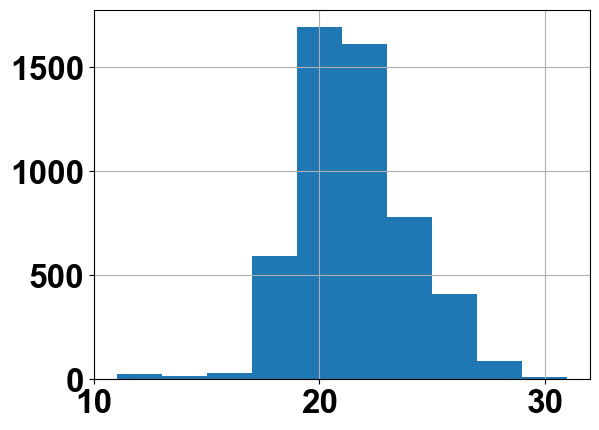

In [127]:
data = pd.concat([long_nostart])
data.intial_distance[data.intial_distance>10].hist()

<AxesSubplot: >

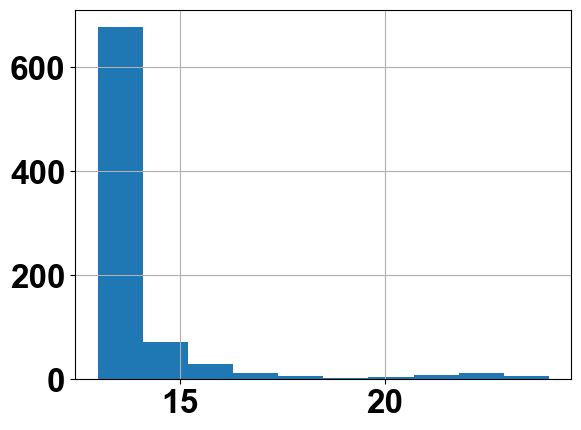

In [128]:
data = pd.concat([short_nostart])
data.intial_distance[data.intial_distance>12].hist()

<AxesSubplot: >

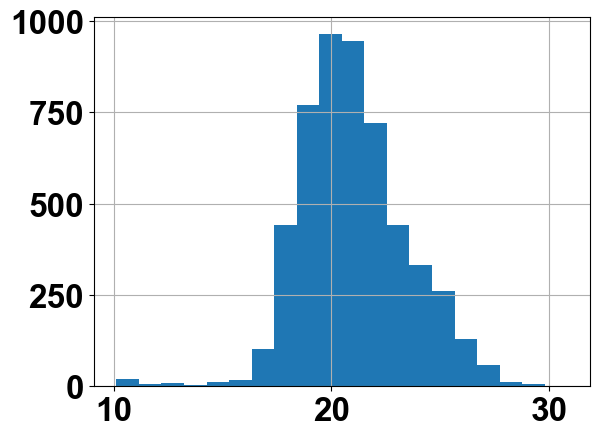

In [116]:
data = pd.concat([long_nostart])
data.intial_distance[data.intial_distance>=10].hist(bins=20)